# Load Timeseries Data

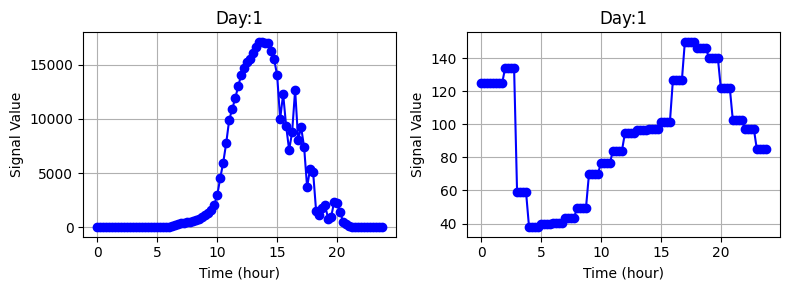

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from modules.solar import PVdata
from modules.economy import ElecPrice

pv_data_path = './data/timeseries-slimpark-2022.csv'
price_data_path='./data/day_ahead_prices_2022.csv'
PV_panel = PVdata(pv_data_path)
elec_price = ElecPrice(price_data_path)

expanded_pv = np.hstack([np.zeros(1,), PV_panel.day_data])
expanded_price = np.hstack([np.zeros(1,), elec_price.day_price_data])

# Create time axis for original and expanded data
time_axis_original = np.arange(0, 24, 1)
time_axis_expanded = np.arange(0, 24, 0.25)

# Plot the original and expanded data in subplots
plt.figure(figsize=(8, 3))
plt.subplot(1,2,1)
plt.plot(time_axis_expanded, expanded_pv[1:], marker='o', linestyle='-', color='b', label='Expanded Data (15 minute)')
plt.xlabel('Time (hour)')
plt.ylabel('Signal Value')
plt.title(f"Day:{PV_panel.day_num}")
plt.grid(True)

plt.subplot(1,2,2)
# plt.plot(time_axis_original.astype(str), price_day[1:], marker='o', linestyle='-', color='g', label='Original Data (1 hour)')
plt.plot(time_axis_expanded, expanded_price[1:], marker='o', linestyle='-', color='b', label='Expanded Data (15 minute)')
plt.xlabel('Time (hour)')
plt.ylabel('Signal Value')
plt.title(f"Day:{PV_panel.day_num}")
plt.grid(True)
plt.tight_layout()
plt.show()


### EV profiles

Total number of profiles: 2920


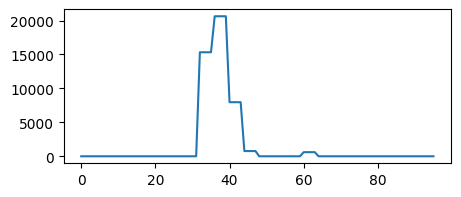

In [2]:
import pandas as pd
import numpy as np

# Load and preprocess data
df = pd.read_csv('data/power_and_active_sessions_cp_UT.csv')
df['date'] = pd.to_datetime(df['times']).dt.date

# Group by date
grouped = df.groupby('date')

# Initialize storage dictionaries
evse_cols = ['evse_1_wh', 'evse_2_wh', 'evse_3_wh', 'evse_4_wh']
evse_data = {col: [] for col in evse_cols}
power_profiles = []

# Iterate over each day's group
for date, group in grouped:
    if len(group) == 96:
        for col in evse_cols:
            evse_data[col].append(group[col].to_numpy())
        power_profiles.append(group['power'].to_numpy())

# Convert lists to numpy arrays
for col in evse_cols:
    evse_data[col] = np.array(evse_data[col])
    evse_data[col] = np.where(evse_data[col] < 10, 0, evse_data[col])

power_profiles = np.array(power_profiles)
power_profiles = np.where(power_profiles < 10, 0, power_profiles)

# Optional: unpack if you want the original variable names
evse_1_wh, evse_2_wh, evse_3_wh, evse_4_wh = (evse_data[col] for col in evse_cols)

all_profiles = np.concatenate((evse_1_wh, evse_2_wh, evse_3_wh, evse_4_wh), axis=0)
print(f"Total number of profiles: {len(all_profiles)}")

plt.figure(figsize=(5, 2))
plt.plot(all_profiles[12])

### PV forecasts

Total number of profiles: 730


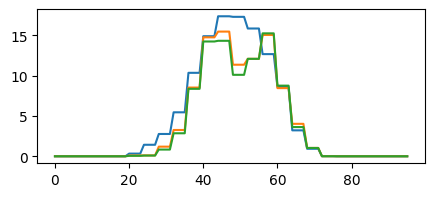

In [3]:
# Initialize storage dictionaries
pv_cols = ['pv_wh', 'pv_forecast_day_ahead_wh', 'pv_forecast_intraday_wh']
pv_data = {col: [] for col in pv_cols}

# Iterate over each day's group
for date, group in grouped:
    if len(group) == 96:
        for col in pv_cols:
            pv_data[col].append(group[col].to_numpy())

# Convert lists to numpy arrays
for col in pv_data:
    pv_data[col] = np.array(pv_data[col])
    pv_data[col] = np.where(pv_data[col] < 0, pv_data[col], 0)

# Optional: unpack if you want the original variable names
pv_wh, pv_forecast_day_ahead_wh, pv_forecast_intraday_wh = (pv_data[col] for col in pv_cols)

all_pv_profiles = -np.stack((pv_wh, pv_forecast_day_ahead_wh, pv_forecast_intraday_wh), axis=-1)
print(f"Total number of profiles: {len(all_pv_profiles)}")

plt.figure(figsize=(5, 2))
plt.plot(all_pv_profiles[100]/1000)

# Gaussian Mixture Model (GMM)

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
from sklearn.cluster import KMeans
import numpy as np

class OnlineGMM:
    def __init__(self, num_components=2, buffer_size=200, lr=0.05):
        """Initialize the Online GMM with given parameters."""
        self.K = num_components
        self.buffer = deque(maxlen=buffer_size)
        
        # GMM parameters as PyTorch parameters
        self.means = nn.Parameter(torch.randn(self.K, 1))
        self.log_vars = nn.Parameter(torch.zeros(self.K, 1))
        self.logits = nn.Parameter(torch.zeros(self.K))
        
        # Optimizer
        self.optimizer = optim.Adam([self.means, self.log_vars, self.logits], lr=lr)

    def initialize_with_kmeans(self):
        """Initialize GMM means using KMeans on the buffer."""
        if len(self.buffer) < self.K:
            print("Not enough data to initialize with KMeans.")
            return
        
        data = np.array(self.buffer).reshape(-1, 1)
        kmeans = KMeans(n_clusters=self.K, n_init='auto').fit(data)
        centers = kmeans.cluster_centers_
        # Update the means with the KMeans centers
        with torch.no_grad():
            self.means.copy_(torch.tensor(centers, dtype=torch.float32))

    def gaussian_pdf(self, x, mu, log_var):
        """Compute the Gaussian probability density function."""
        var = torch.exp(log_var)
        return torch.exp(-0.5 * (x - mu)**2 / var) / torch.sqrt(2 * torch.pi * var)

    def update_model(self):
        """Perform one gradient update with the current buffer."""
        # Convert buffer to tensor
        x = torch.tensor(list(self.buffer), dtype=torch.float32).unsqueeze(1)
        
        # Gradient step
        self.optimizer.zero_grad()
        weights = torch.softmax(self.logits, dim=0)
        probs = torch.stack([w * self.gaussian_pdf(x, mu, lv) 
                             for w, mu, lv in zip(weights, self.means, self.log_vars)], dim=0)
        total_prob = torch.sum(probs, dim=0)
        nll = -torch.sum(torch.log(total_prob + 1e-8)) / len(x)
        nll.backward()
        self.optimizer.step()
        return nll.item()
    
    def sample(self, num_samples=1):
        """Sample from the GMM."""
        with torch.no_grad():
            weights = torch.softmax(self.logits, dim=0)
            components = torch.multinomial(weights, num_samples, replacement=True)
            samples = torch.normal(self.means[components], torch.exp(0.5 * self.log_vars[components]))
            return samples.numpy().flatten()

# Mixture Density Network (MDN)

c:\Users\HeydarianArdakaniA\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\HeydarianArdakaniA\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\HeydarianArdakaniA\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


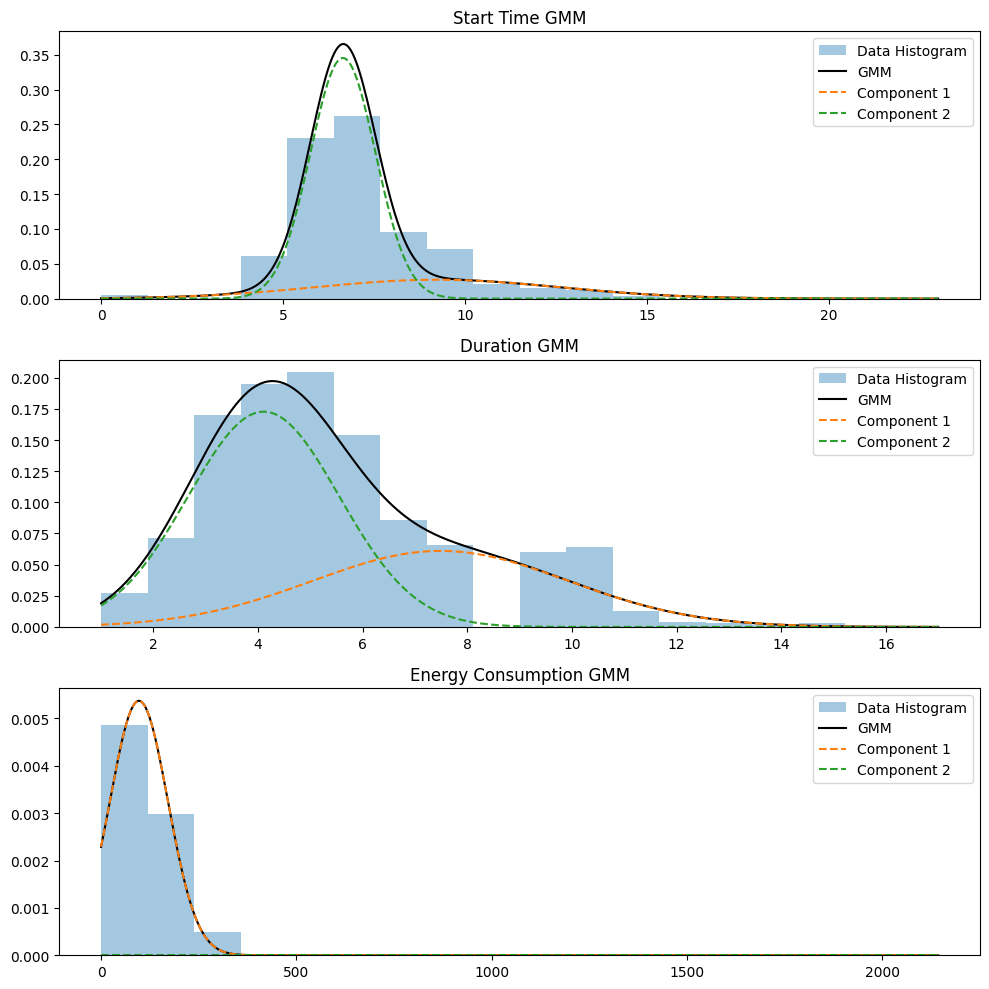

In [5]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# Assume all_profiles is defined
start_times, durations, energy_consumptions = [], [], []

# Extract features from all_profiles
for prof_id in np.unique(np.where(all_profiles > 10)[0]):
    profile = all_profiles[prof_id]
    active_indices = np.where(profile > 0)[0]
    if len(active_indices) == 0:
        continue
    start = active_indices[0] / 4
    duration = len(active_indices) / 4
    energy = profile[active_indices].sum()/1000
    start_times.append(start)
    durations.append(duration)
    energy_consumptions.append(energy)

# Function to fit an OnlineGMM and return components for plotting
def fit_gmm(data):
    gmm = OnlineGMM(num_components=2, buffer_size=2000, lr=0.05)
    data = np.array(data)

    for point in data:
        gmm.buffer.append(point)
        if len(gmm.buffer) < 20:
            continue
        elif len(gmm.buffer) == 20:
            gmm.initialize_with_kmeans()
        else:
            gmm.update_model()
    
    return gmm, data

# Fit GMMs and keep data as well
gmm_results = {
    "Start Time": fit_gmm(start_times),
    "Duration": fit_gmm(durations),
    "Energy Consumption": fit_gmm(energy_consumptions)
}

# Plotting in 3 subplots with appropriate ranges
fig, axes = plt.subplots(3, 1, figsize=(10, 10))

for ax, (title, (gmm, data)) in zip(axes, gmm_results.items()):
    x_vals = torch.linspace(min(data), max(data), 400).unsqueeze(1)
    weights = torch.softmax(gmm.logits, dim=0)
    components = [w * gmm.gaussian_pdf(x_vals, mu, lv) for w, mu, lv in zip(weights, gmm.means, gmm.log_vars)]
    mixture = torch.sum(torch.stack(components), dim=0)

    ax.hist(data, bins=18, density=True, alpha=0.4, label='Data Histogram')
    ax.plot(x_vals.detach(), mixture.detach(), color='black', label='GMM')
    for i, comp in enumerate(components):
        ax.plot(x_vals.detach(), comp.detach(), '--', label=f'Component {i+1}')
    ax.set_title(f'{title} GMM')
    ax.legend()

plt.tight_layout()
plt.show()


In [6]:
ev_data = torch.tensor(np.stack([start_times, durations, energy_consumptions], axis=1))

In [7]:
import torch.nn.functional as F

class MultivariateMDN(nn.Module):
    def __init__(self, n_components=3, output_dim=3):
        super().__init__()
        self.n_components = n_components
        self.output_dim = output_dim
        hidden_dim = 64

        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),  # you can use input=0 if unconditional
            nn.ReLU(),
        )

        self.pi = nn.Linear(hidden_dim, n_components)
        self.mu = nn.Linear(hidden_dim, n_components * output_dim)
        self.sigma = nn.Linear(hidden_dim, n_components * output_dim)

    def forward(self, x):
        h = self.net(x)
        pi = F.softmax(self.pi(h), dim=-1)  # (B, K)
        mu = self.mu(h).view(-1, self.n_components, self.output_dim)  # (B, K, D)
        sigma = torch.exp(self.sigma(h)).view(-1, self.n_components, self.output_dim) + 1e-6
        return pi, mu, sigma

    def log_prob(self, target, pi, mu, sigma):
        # target shape: (B, D)
        target = target.unsqueeze(1)  # (B, 1, D)
        prob = torch.exp(-0.5 * ((target - mu) / sigma)**2) / (sigma * (2 * torch.pi)**0.5)
        prob = prob.prod(dim=-1)  # Multiply across dimensions to get joint
        weighted_prob = pi * prob
        return torch.log(weighted_prob.sum(dim=-1) + 1e-8)

    def sample(self, batch_size=1):
        pi, mu, sigma = self.forward(torch.zeros((batch_size, 1)))
        dist = torch.distributions.Categorical(pi)
        idx = dist.sample()  # (B,)
        mu_chosen = mu[torch.arange(batch_size), idx]      # (B, D)
        sigma_chosen = sigma[torch.arange(batch_size), idx]
        eps = torch.randn_like(mu_chosen)
        return mu_chosen + sigma_chosen * eps


model = MultivariateMDN(n_components=3, output_dim=3)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

for epoch in range(1000):
    batch = ev_data  # shape: (B, 3)
    target = batch

    pi, mu, sigma = model(torch.rand((batch.shape[0], 1)))  # unconditional
    logp = model.log_prob(target, pi, mu, sigma)
    loss = -logp.mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, loss = {loss.item():.4f}")


Epoch 0, loss = 18.4068
Epoch 100, loss = 10.6293
Epoch 200, loss = 10.5172
Epoch 300, loss = 10.2360
Epoch 400, loss = 10.0856
Epoch 500, loss = 10.0800
Epoch 600, loss = 10.0818
Epoch 700, loss = 10.0784
Epoch 800, loss = 10.0798
Epoch 900, loss = 10.0790


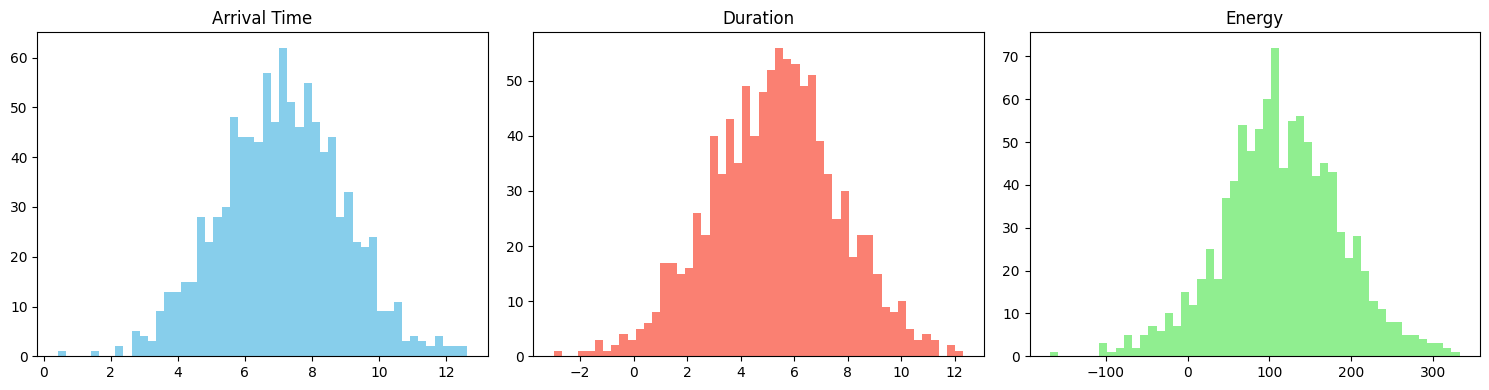

In [8]:
samples = model.sample(batch_size=1000)  # shape: (1000, 3)
arrival_samples = samples[:, 0]
duration_samples = samples[:, 1]
energy_samples = samples[:, 2]

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(arrival_samples.cpu().detach().numpy(), bins=50, color='skyblue')
axes[0].set_title('Arrival Time')

axes[1].hist(duration_samples.cpu().detach().numpy(), bins=50, color='salmon')
axes[1].set_title('Duration')

axes[2].hist(energy_samples.cpu().detach().numpy(), bins=50, color='lightgreen')
axes[2].set_title('Energy')

plt.tight_layout()
plt.show()


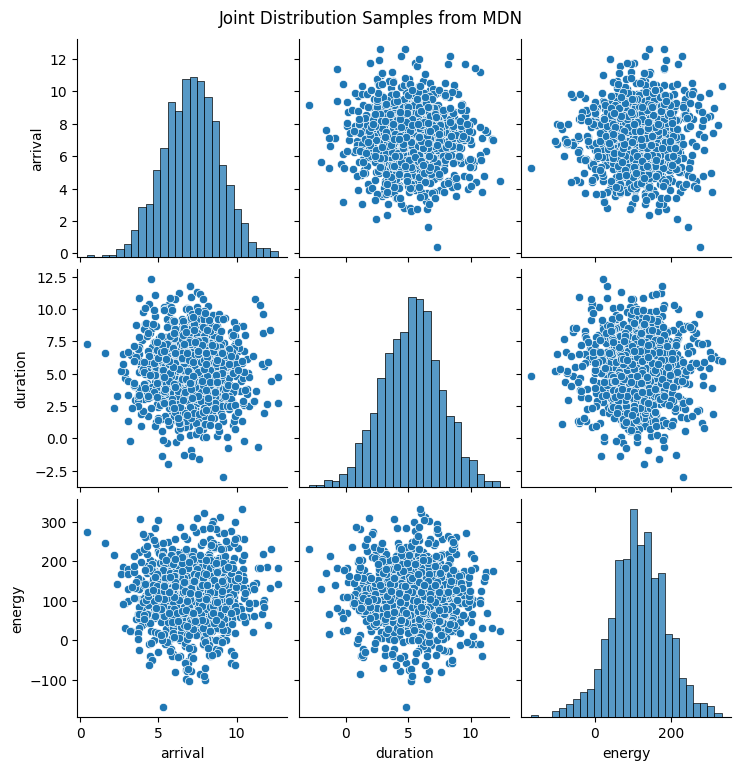

In [9]:
import seaborn as sns
import pandas as pd

df = pd.DataFrame({
    "arrival": arrival_samples.cpu().detach().numpy(),
    "duration": duration_samples.cpu().detach().numpy(),
    "energy": energy_samples.cpu().detach().numpy()
})

sns.pairplot(df)
plt.suptitle("Joint Distribution Samples from MDN", y=1.02)
plt.show()


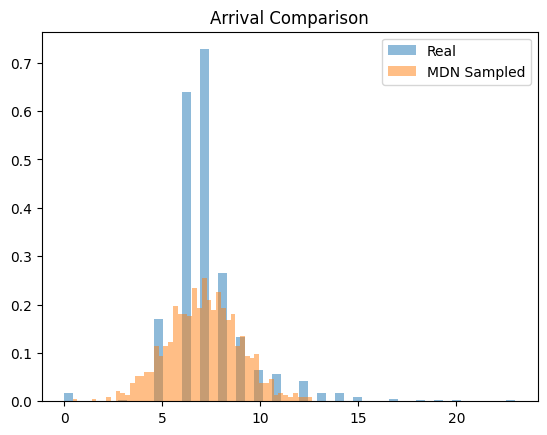

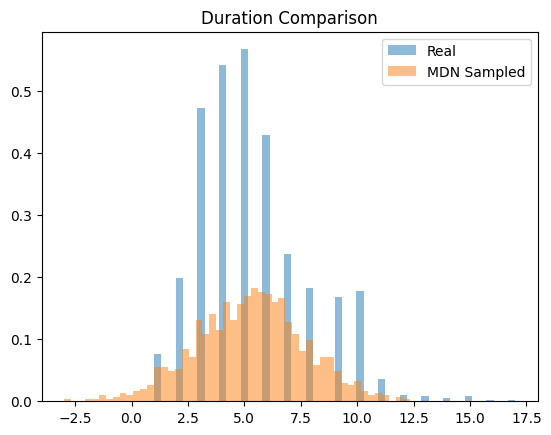

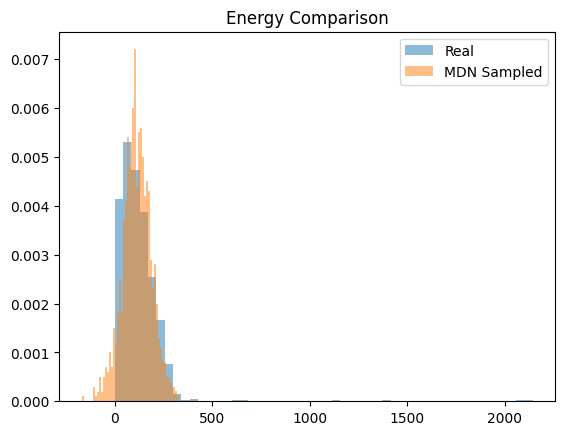

In [10]:
real_df = pd.DataFrame(ev_data, columns=["arrival", "duration", "energy"])
fake_df = pd.DataFrame(samples.cpu().detach().numpy(), columns=["arrival", "duration", "energy"])

# Overlay histograms
for col in ["arrival", "duration", "energy"]:
    plt.hist(real_df[col], bins=50, alpha=0.5, label='Real', density=True)
    plt.hist(fake_df[col], bins=50, alpha=0.5, label='MDN Sampled', density=True)
    plt.title(f"{col.capitalize()} Comparison")
    plt.legend()
    plt.show()


In [13]:
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F

class MDN(nn.Module):
    def __init__(self, input_dim, output_dim, n_components=3, hidden_dim=64):
        super().__init__()
        self.n_components = n_components
        self.output_dim = output_dim

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
        )
        self.pi = nn.Linear(hidden_dim, n_components)
        self.mu = nn.Linear(hidden_dim, n_components * output_dim)
        self.sigma = nn.Linear(hidden_dim, n_components * output_dim)

    def forward(self, x):
        h = self.net(x)
        pi = F.softmax(self.pi(h), dim=-1)                                     # (B, K)
        mu = self.mu(h).view(-1, self.n_components, self.output_dim)           # (B, K, D)
        sigma = torch.exp(self.sigma(h)).view(-1, self.n_components, self.output_dim) + 1e-6
        return pi, mu, sigma

    def log_prob(self, target, pi, mu, sigma):
        target = target.unsqueeze(1)                                           # (B, 1, D)
        prob = torch.exp(-0.5 * ((target - mu) / sigma)**2) / (sigma * (2 * np.pi)**0.5)
        prob = prob.prod(dim=-1)                                               # (B, K)
        weighted = pi * prob
        return torch.log(weighted.sum(dim=-1) + 1e-8)                           # (B,)

    def sample(self, pi, mu, sigma):
        batch_size = pi.size(0)
        cat = torch.distributions.Categorical(pi)
        indices = cat.sample()                                                 # (B,)
        mu_selected = mu[torch.arange(batch_size), indices]                   # (B, D)
        sigma_selected = sigma[torch.arange(batch_size), indices]
        eps = torch.randn_like(mu_selected)
        return mu_selected + sigma_selected * eps                              # (B, D)

mdn1 = MDN(input_dim=1, output_dim=1)       # p(arrival)
mdn2 = MDN(input_dim=1, output_dim=1)       # p(duration | arrival)
mdn3 = MDN(input_dim=2, output_dim=1)       # p(energy | arrival, duration)

optim = torch.optim.Adam(
    list(mdn1.parameters()) +
    list(mdn2.parameters()) +
    list(mdn3.parameters()), lr=1e-2
)

for epoch in range(5001):
    batch = ev_data  # shape: (B, 3)
    arrival = batch[:, 0:1].float()
    duration = batch[:, 1:2].float()
    energy = batch[:, 2:3].float()

    # MDN1: p(arrival)
    pi1, mu1, sigma1 = mdn1(torch.rand(arrival.shape))  # cast to float32  # dummy input
    logp1 = mdn1.log_prob(arrival, pi1, mu1, sigma1)

    # MDN2: p(duration | arrival)
    pi2, mu2, sigma2 = mdn2(arrival)
    logp2 = mdn2.log_prob(duration, pi2, mu2, sigma2)

    # MDN3: p(energy | arrival, duration)
    x3 = torch.cat([arrival, duration], dim=1)
    pi3, mu3, sigma3 = mdn3(x3)
    logp3 = mdn3.log_prob(energy, pi3, mu3, sigma3)

    # Total negative log-likelihood loss
    loss = -(logp1 + logp2 + logp3).mean()

    optim.zero_grad()
    loss.backward()
    optim.step()

    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Loss = {loss.item():.4f}")

Epoch 0, Loss = 49.2838
Epoch 1000, Loss = 9.2642
Epoch 2000, Loss = 9.1886
Epoch 3000, Loss = 9.2856
Epoch 4000, Loss = 9.2700
Epoch 5000, Loss = 9.2628


c:\Users\HeydarianArdakaniA\AppData\Local\anaconda3\Lib\site-packages\pandas\core\dtypes\cast.py:375: RuntimeWarning: invalid value encountered in cast
  new_result = trans(result).astype(dtype)


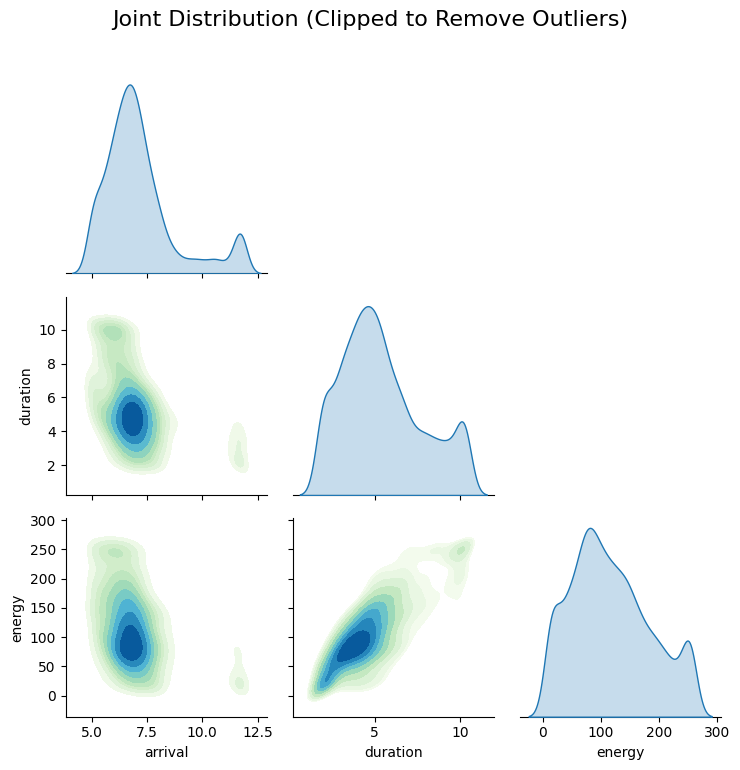

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def sample_autoregressive(mdn1, mdn2, mdn3, n_samples=1000):
    device = next(mdn1.parameters()).device

    # Step 1: sample x1 ~ p(x1)
    dummy_input = torch.rand(n_samples, 1).to(device)
    pi1, mu1, sigma1 = mdn1(dummy_input)
    x1 = mdn1.sample(pi1, mu1, sigma1)  # shape: (N, 1)

    # Step 2: sample x2 ~ p(x2 | x1)
    pi2, mu2, sigma2 = mdn2(x1)
    x2 = mdn2.sample(pi2, mu2, sigma2)  # shape: (N, 1)

    # Step 3: sample x3 ~ p(x3 | x1, x2)
    x12 = torch.cat([x1, x2], dim=1)
    pi3, mu3, sigma3 = mdn3(x12)
    x3 = mdn3.sample(pi3, mu3, sigma3)  # shape: (N, 1)

    # Final samples (N, 3)
    samples = torch.cat([x1, x2, x3], dim=1).detach().cpu().numpy()
    return samples


# Generate samples
samples = sample_autoregressive(mdn1, mdn2, mdn3, n_samples=5000)

# Convert to DataFrame for seaborn
df_samples = pd.DataFrame(samples, columns=["arrival", "duration", "energy"])

def clip_outliers(df, lower=0.01, upper=0.99):
    return df.apply(lambda x: x.clip(lower=x.quantile(lower), upper=x.quantile(upper)))

df_clipped = clip_outliers(df_samples, lower=0.05, upper=0.95)

# Pairplot (joint distribution visualization)
# sns.pairplot(df_clipped, kind="kde", corner=True, plot_kws={"fill": True, "thresh": 0.05}
             
# sns.set(style="whitegrid")

g = sns.pairplot(
    df_clipped,
    kind="kde",  # use KDE for joint distributions
    diag_kind="kde",  # KDE for the diagonal too
    plot_kws={'cmap': 'GnBu', 'fill': True, 'thresh': 0.2},
    corner=True  # optional: only show lower triangle
)

plt.suptitle("Joint Distribution (Clipped to Remove Outliers)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [15]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors

def truncate_colormap(cmap_name, minval=0.3, maxval=1.0, n=100):
    cmap = cm.get_cmap(cmap_name)
    new_cmap = colors.LinearSegmentedColormap.from_list(
        f'trunc({cmap_name},{minval:.2f},{maxval:.2f})',
        cmap(np.linspace(minval, maxval, n))
    )
    return new_cmap

dark_gnbu = truncate_colormap('GnBu', 0.0, 1.0)


C:\Users\HeydarianArdakaniA\AppData\Local\Temp\ipykernel_18592\21089964.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


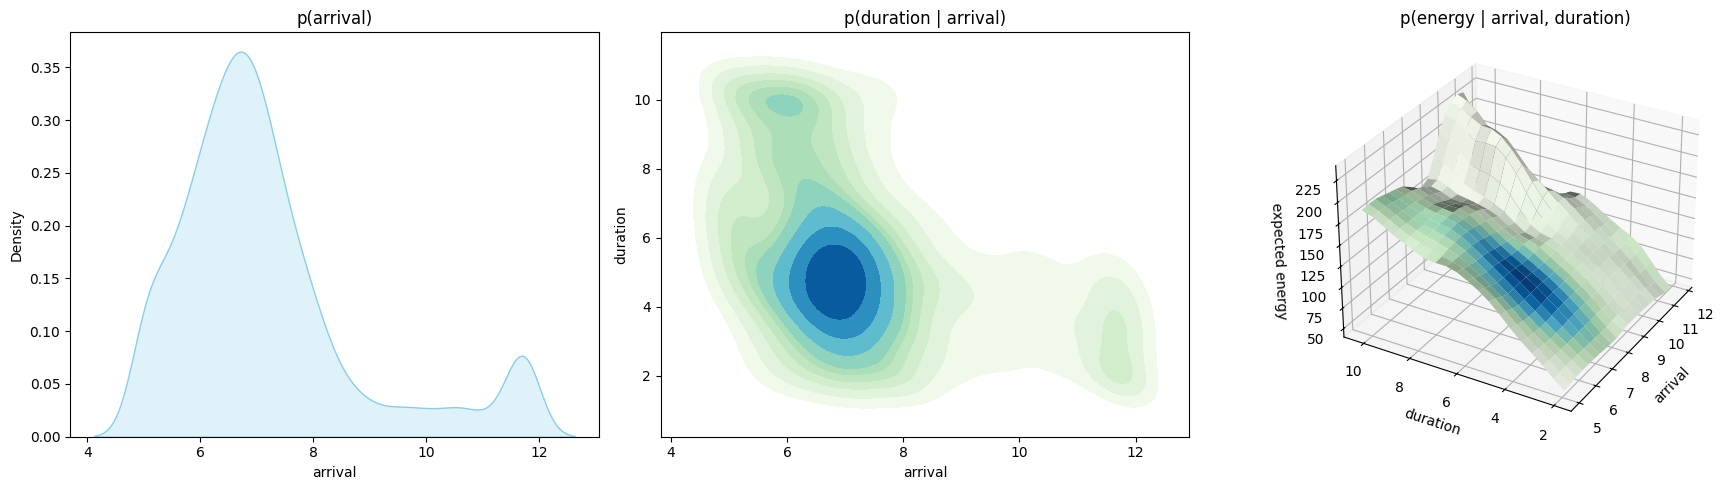

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde

fig = plt.figure(figsize=(18, 5))

# 1D: p(arrival)
ax1 = fig.add_subplot(1, 3, 1)
sns.kdeplot(df_clipped['arrival'], fill=True, color='skyblue', ax=ax1)
ax1.set_title('p(arrival)')


# 2D: p(duration | arrival)
ax2 = fig.add_subplot(1, 3, 2)
sns.kdeplot(
    x=df_clipped['arrival'],
    y=df_clipped['duration'],
    fill=True,
    cmap=dark_gnbu,
    thresh=0.05,
    ax=ax2
)
ax2.set_title('p(duration | arrival)')

'''
# 3D: p(energy | arrival, duration)
ax3 = fig.add_subplot(2, 2, 3, projection='3d')
ax3.scatter(df_clipped['arrival'], df_clipped['duration'], df_clipped['energy'], c=df_clipped['energy'], cmap=dark_gnbu, s=5)
ax3.set_xlabel('arrival')
ax3.set_ylabel('duration')
ax3.set_zlabel('energy')
ax3.set_title('p(energy | arrival, duration)')
'''

# 3D: p(energy | arrival, duration) with density color
ax4 = fig.add_subplot(1, 3, 3, projection='3d')
# Prepare data for KDE
values = df_clipped[['arrival', 'duration', 'energy']].T.values
kde = gaussian_kde(values)

# Create meshgrid for arrival and duration
x = np.linspace(df_clipped['arrival'].min(), df_clipped['arrival'].max(), 20)
y = np.linspace(df_clipped['duration'].min(), df_clipped['duration'].max(), 20)
X, Y = np.meshgrid(x, y)
Z = np.zeros_like(X)
density_values = np.zeros_like(X)

# Compute expected energy and density
energy_range = np.linspace(df_clipped['energy'].min(), df_clipped['energy'].max(), 100)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        # Evaluate KDE density over energy range
        density = np.array([kde([X[i, j], Y[i, j], e])[0] for e in energy_range])
        # Compute marginal density p(arrival, duration) by integrating over energy
        density_values[i, j] = np.sum(density) * (energy_range[1] - energy_range[0])
        # Compute expected energy: sum(density * energy) / sum(density)
        if np.sum(density) > 0:
            Z[i, j] = np.sum(density * energy_range) / np.sum(density)
        else:
            Z[i, j] = np.nanmean(df_clipped['energy'])  # Fallback to mean energy

# Normalize density_values for colormap (0 to 1)
density_norm = (density_values - density_values.min()) / (density_values.max() - density_values.min())

# Plot the surface with density color using custom colormap
surf = ax4.plot_surface(X, Y, Z, facecolors=dark_gnbu(density_norm), edgecolor='none', alpha=1)

ax4.set_xlabel('arrival')
ax4.set_ylabel('duration')
ax4.set_zlabel('expected energy')
ax4.set_title('p(energy | arrival, duration)')
# fig.colorbar(surf, shrink=0.5, aspect=10, label='Density')

# Set rotation: elevation (30 degrees) and azimuth (-150 degrees)
ax4.view_init(elev=30, azim=-150)

plt.tight_layout()
plt.show()

# Generator

In [17]:
samples = sample_autoregressive(mdn1, mdn2, mdn3, n_samples=10)
arrival_samples = samples[:, 0]
duration_samples = samples[:, 1]
energy_samples = samples[:, 2]

# Filter out durations less than 0.5
mask = duration_samples >= 0.5
arrival_samples = arrival_samples[mask]
duration_samples = duration_samples[mask]
energy_samples = energy_samples[mask]

print("Sampled Arrival Times:", arrival_samples)
print("Sampled Durations:", duration_samples)
print("Sampled Energy Consumptions:", energy_samples)

Sampled Arrival Times: [ 5.5151587  5.3211193  6.7024407 14.178228   5.302602   5.1838646
  4.950845   6.8879404  9.115161 ]
Sampled Durations: [ 3.6110973  5.835113   3.7748058  4.9600663  8.421736  10.285981
  8.284808   5.33757    5.940863 ]
Sampled Energy Consumptions: [ 95.87737  128.25467    9.103119  54.764885 148.39157  220.06421
 243.4466    79.13701   39.76117 ]


In [18]:
def sample_duration_given_arrival(mdn2, arrival):
    """Sample duration given a specific arrival time."""
    # sample x2 ~ p(x2 | x1)
    arrival_tensor = torch.tensor(arrival).reshape(-1,1).float()  # shape: (1, 1)
    pi2, mu2, sigma2 = mdn2(arrival_tensor)
    duration_sample = mdn2.sample(pi2, mu2, sigma2)  # shape: (1, 1)
    return duration_sample.item()

sample_duration_given_arrival(mdn2, 9.277739)

4.773039817810059

Sampled Arrival Times: [5.493372  7.339837  6.601911  6.7314878]
Sampled Durations: [9.855771  6.7716265 8.933445  5.0037866]
Sampled Energy Consumptions: [158.78189   35.138733 166.86542   28.574219]


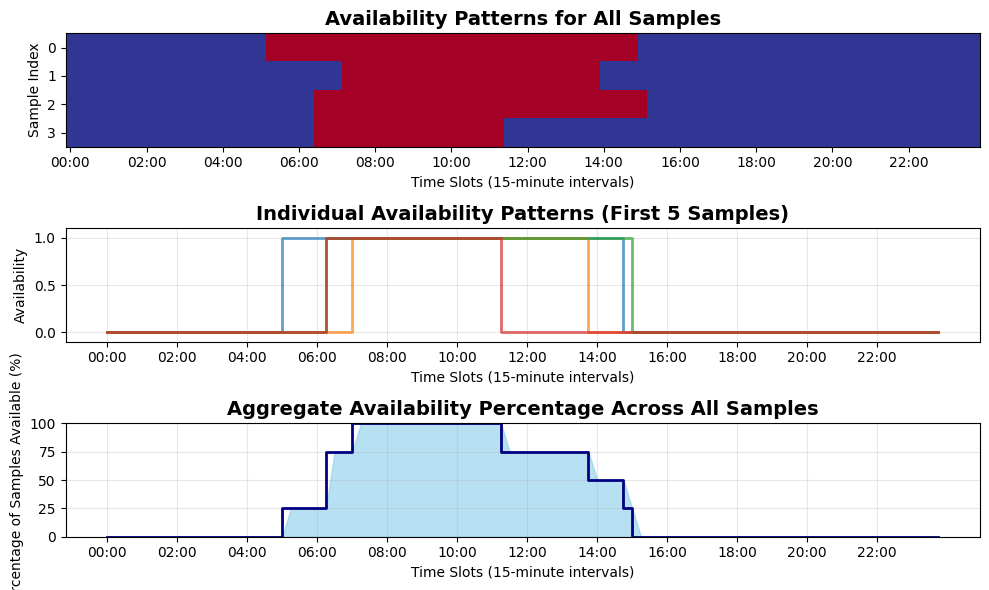


AVAILABILITY SUMMARY
Number of valid samples: 4
Average availability duration: 7.64 hours
Peak availability time: 07:15
Maximum availability percentage: 100.0%
Minimum availability percentage: 0.0%

INDIVIDUAL SAMPLE DETAILS:
--------------------------------------------------------------------------------
Sample   Arrival      Duration     Energy       Departure   
--------------------------------------------------------------------------------
1        05:29        9.86        h 158.78       15:20       
2        07:20        6.77        h 35.14        14:06       
3        06:36        8.93        h 166.87       15:32       
4        06:43        5.00        h 28.57        11:44       


In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Your existing code
samples = sample_autoregressive(mdn1, mdn2, mdn3, n_samples=5000)
arrival_samples = samples[:, 0]
duration_samples = samples[:, 1]
energy_samples = samples[:, 2]

# Filter out durations less than 0.5
mask = (0<=arrival_samples) * (5<=duration_samples) * (0<=energy_samples)
arrival_samples = arrival_samples[mask][:4]
duration_samples = duration_samples[mask][:4]
energy_samples = energy_samples[mask][:4]

print("Sampled Arrival Times:", arrival_samples)
print("Sampled Durations:", duration_samples)
print("Sampled Energy Consumptions:", energy_samples)

def compute_availability(arrival_times, durations, n_slots=96):
    """
    Compute availability vectors for multiple samples (vectorized)
    
    Args:
        arrival_times: array of arrival times (in hours, will be converted to 15-min slots)
        durations: array of durations (in hours, will be converted to 15-min slots)
        n_slots: number of time slots (default 96 for 24 hours * 4 intervals)
    
    Returns:
        availability_matrix: shape (n_samples, n_slots)
    """
    n_samples = len(arrival_times)
    
    # Convert hours to 15-minute slots (vectorized)
    arrival_slots = np.clip((arrival_times * 4).astype(int), 0, n_slots - 1)
    duration_slots = (durations * 4).astype(int)
    departure_slots = arrival_slots + duration_slots
    
    # Create time slot indices for broadcasting
    slot_indices = np.arange(n_slots)  # Shape: (n_slots,)
        
    start_mask = slot_indices >= arrival_slots[:, None]  # (n_samples, n_slots)
    
    # Handle normal case (departure within day) and wrap-around case
    normal_case = departure_slots <= n_slots
    end_mask_normal = slot_indices < departure_slots[:, None]  # (n_samples, n_slots)
    end_mask_wraparound = slot_indices < (departure_slots % n_slots)[:, None]  # (n_samples, n_slots)
    
    # Create availability matrix
    availability_matrix = np.zeros((n_samples, n_slots), dtype=int)
    
    # Normal case: within same day
    normal_mask = normal_case[:, None]  # (n_samples, 1)
    availability_matrix = np.where(
        normal_mask,
        start_mask & end_mask_normal,
        start_mask | end_mask_wraparound  # Wrap-around case
    )
    
    return availability_matrix.astype(int)

# Compute availability for all samples
availability_matrix = compute_availability(arrival_samples, duration_samples)

# Create visualizations
fig, axes = plt.subplots(3, 1, figsize=(10, 6))

# 1. Heatmap of all availability patterns
im1 = axes[0].imshow(availability_matrix, cmap='RdYlBu_r', aspect='auto', interpolation='nearest')
axes[0].set_title('Availability Patterns for All Samples', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Time Slots (15-minute intervals)')
axes[0].set_ylabel('Sample Index')
axes[0].set_xticks(range(0, 96, 8))
axes[0].set_xticklabels([f'{i//4:02d}:00' for i in range(0, 96, 8)])
# plt.colorbar(im1, ax=axes[0], label='Available (1) / Not Available (0)')

# 2. Individual availability patterns (first 5 samples)
n_show = min(5, len(arrival_samples))
for i in range(n_show):
    axes[1].plot(availability_matrix[i], alpha=0.7, linewidth=2, drawstyle='steps', 
                label=f'Sample {i+1} (A:{arrival_samples[i]:.1f}h, D:{duration_samples[i]:.1f}h)')

axes[1].set_title('Individual Availability Patterns (First 5 Samples)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Time Slots (15-minute intervals)')
axes[1].set_ylabel('Availability')
axes[1].set_xticks(range(0, 96, 8))
axes[1].set_xticklabels([f'{i//4:02d}:00' for i in range(0, 96, 8)])
# axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(-0.1, 1.1)

# 3. Aggregate availability (percentage of samples available at each time slot)
aggregate_availability = np.mean(availability_matrix, axis=0) * 100
axes[2].fill_between(range(96), aggregate_availability, alpha=0.6, color='skyblue')
axes[2].plot(aggregate_availability, color='navy', linewidth=2, drawstyle='steps')
axes[2].set_title('Aggregate Availability Percentage Across All Samples', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Time Slots (15-minute intervals)')
axes[2].set_ylabel('Percentage of Samples Available (%)')
axes[2].set_xticks(range(0, 96, 8))
axes[2].set_xticklabels([f'{i//4:02d}:00' for i in range(0, 96, 8)])
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim(0, 100)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*50)
print("AVAILABILITY SUMMARY")
print("="*50)
print(f"Number of valid samples: {len(arrival_samples)}")
print(f"Average availability duration: {np.mean(duration_samples):.2f} hours")
print(f"Peak availability time: {np.argmax(aggregate_availability)//4:02d}:{(np.argmax(aggregate_availability)%4)*15:02d}")
print(f"Maximum availability percentage: {np.max(aggregate_availability):.1f}%")
print(f"Minimum availability percentage: {np.min(aggregate_availability):.1f}%")

# Print individual sample details
print("\nINDIVIDUAL SAMPLE DETAILS:")
print("-" * 80)
print(f"{'Sample':<8} {'Arrival':<12} {'Duration':<12} {'Energy':<12} {'Departure':<12}")
print("-" * 80)
for i in range(len(arrival_samples)):
    departure = arrival_samples[i] + duration_samples[i]
    arrival_time = f"{int(arrival_samples[i]):02d}:{int((arrival_samples[i] % 1) * 60):02d}"
    departure_time = f"{int(departure):02d}:{int((departure % 1) * 60):02d}"
    print(f"{i+1:<8} {arrival_time:<12} {duration_samples[i]:<12.2f}h {energy_samples[i]:<12.2f} {departure_time:<12}")

In [20]:
availability_matrix.shape

(4, 96)

(4,) (97, 4)


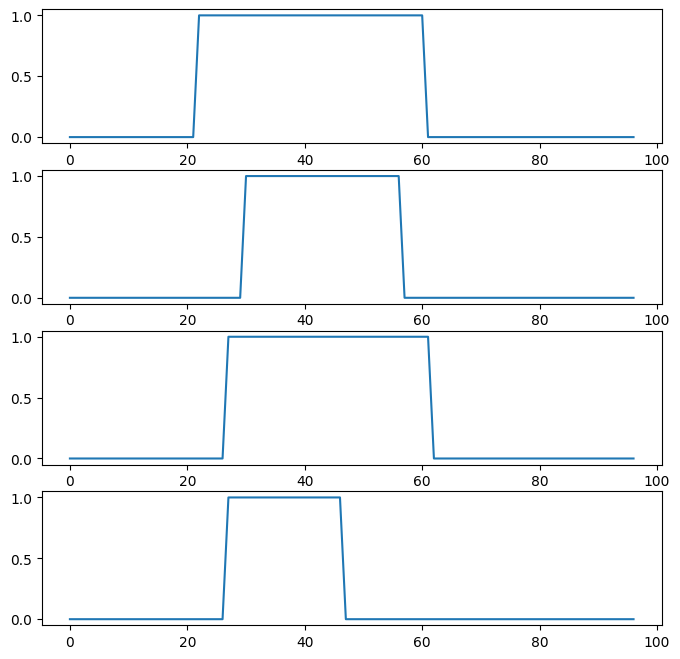

In [21]:
ev_demand_initial_sample = energy_samples/4
charger_availability_data = np.vstack([np.zeros((1, len(availability_matrix))), availability_matrix.T])

print(ev_demand_initial_sample.shape, charger_availability_data.shape)

plt.figure(figsize=(8, 8))
for i in range(len(availability_matrix)):
    plt.subplot(len(availability_matrix),1,i+1)
    plt.plot(charger_availability_data[:,i])

In [22]:
charger_availability_data.shape

(97, 4)

# with p_grid

In [23]:
expanded_pv

array([ 0.00000000e+00, -0.00000000e+00, -0.00000000e+00, -0.00000000e+00,
       -0.00000000e+00, -0.00000000e+00, -0.00000000e+00, -0.00000000e+00,
       -0.00000000e+00, -0.00000000e+00, -0.00000000e+00, -0.00000000e+00,
       -0.00000000e+00, -0.00000000e+00, -0.00000000e+00, -0.00000000e+00,
       -0.00000000e+00, -0.00000000e+00, -0.00000000e+00, -0.00000000e+00,
       -0.00000000e+00, -0.00000000e+00, -0.00000000e+00, -0.00000000e+00,
        3.87777778e+00,  6.17555556e+01,  1.44766667e+02,  2.19922222e+02,
        2.93155556e+02,  3.63088889e+02,  4.23844444e+02,  4.84155556e+02,
        5.45133333e+02,  6.15022222e+02,  7.02477778e+02,  8.21666667e+02,
        9.52655556e+02,  1.10968889e+03,  1.32512222e+03,  1.58364444e+03,
        2.08632222e+03,  2.96233333e+03,  4.54292222e+03,  5.97675556e+03,
        7.77075556e+03,  9.91155556e+03,  1.08957667e+04,  1.18811222e+04,
        1.29962667e+04,  1.40384111e+04,  1.46719222e+04,  1.52378000e+04,
        1.54930889e+04,  

(CVXPY) Jun 16 03:03:43 PM: Encountered unexpected exception importing solver GLOP:
RuntimeError('Unrecognized new version of ortools (9.10.4067). Expected < 9.10.0. Please open a feature request on cvxpy to enable support for this version.')
(CVXPY) Jun 16 03:03:43 PM: Encountered unexpected exception importing solver PDLP:
RuntimeError('Unrecognized new version of ortools (9.10.4067). Expected < 9.10.0. Please open a feature request on cvxpy to enable support for this version.')
                                     CVXPY                                     
                                     v1.5.2                                    
(CVXPY) Jun 16 03:03:43 PM: Your problem has 1067 variables, 1365 constraints, and 0 parameters.
(CVXPY) Jun 16 03:03:43 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Jun 16 03:03:43 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Jun 16 03:03:43 PM: CVXPY will fir

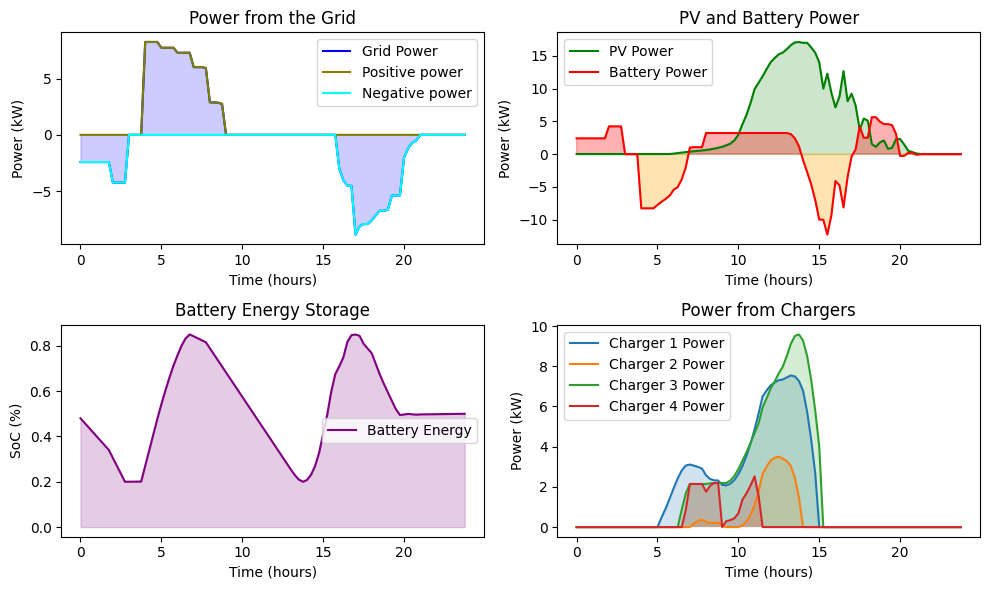

In [24]:
import cvxpy as cp
import numpy as np
import matplotlib.pyplot as plt

# Parameters
num_time_steps = 24*4  # 24 hours * 4 (15-minute resolution)
num_chargers = 4

p_pv = expanded_pv[:num_time_steps+1]/ 1000  # PV power generation over time (size: num_time_steps)
charger_availability = charger_availability_data  # Charger availability (size: num_chargers x num_time_steps)
ev_demand = ev_demand_initial_sample.ravel()  # Demand for each EV (size: num_chargers)
price = expanded_price[:num_time_steps+1]

time_resolution = 0.25  # 15 minutes

# Storage constraints
storage_capacity = 30  # Example capacity
capacity_high_limit = 0.85
capacity_low_limit = 0.2

charge_discharge_limit = 14  # Example charge/discharge limit
p_charger_limit = 11

# Decision Variables
p_chargers = cp.Variable((num_time_steps+1, num_chargers), nonneg=True)
p_grid = cp.Variable(num_time_steps+1)
p_grid_positive = cp.Variable(num_time_steps+1, nonneg=True)
p_grid_negative = cp.Variable(num_time_steps+1, nonneg=True)
p_storage = cp.Variable(num_time_steps+1)
storage_energy = cp.Variable(num_time_steps+1, nonneg=True)
slack = cp.Variable(num_time_steps+1)  # Slack variable for power balance constraints

# Binary variables for big-M method
binary_pos = cp.Variable(num_time_steps+1, boolean=True)

# Big-M constant
M = 1e5

# Constraints
constraints = []

# Charger availability constraints
constraints.append(p_chargers <= charger_availability * p_charger_limit)

# Power balance constraints
constraints.append(p_pv + p_grid + p_storage + slack == cp.sum(p_chargers, axis=1))

constraints.append(storage_energy <= storage_capacity * capacity_high_limit)
constraints.append(storage_energy >= storage_capacity * capacity_low_limit)
constraints.append(p_storage <= charge_discharge_limit)
constraints.append(p_storage >= -charge_discharge_limit)
constraints.append(storage_energy[0] == storage_capacity / 2)  # Initial storage level
constraints.append(storage_energy[-1] == storage_capacity / 2)

constraints.append(storage_energy[1:] == storage_energy[:-1] - p_storage[1:] * time_resolution)

# Initial conditions
# constraints.append(self.p_grid[0] == self.p_grid_initial)
constraints.append(p_grid_positive[0] == 0)
constraints.append(p_grid_negative[0] == 0)

# EV demand constraints
constraints.append(cp.sum(p_chargers * time_resolution, axis=0) >= ev_demand)

# Auxiliary variables constraints
constraints.append(p_grid == p_grid_positive - p_grid_negative)

# Ensure p_grid_positive and p_grid_negative cannot be positive at the same time
constraints.append(binary_pos <= 1)
constraints.append(p_grid_positive <= binary_pos * M)
constraints.append(p_grid_negative <= (1-binary_pos) * M)

# Smoothing constraint to avoid abrupt changes
smoothing_penalty = cp.tv(p_grid_positive) + cp.tv(p_grid_negative) + cp.tv(p_storage) + 2*cp.tv(p_chargers) 

# Objective: Minimize total grid power usage, slack, and smoothing
objective = cp.Minimize(
    cp.sum(p_grid ** 2)+
    cp.sum(cp.multiply(price, p_grid_positive)) -
    cp.sum(cp.multiply(price/2, p_grid_negative)) +
    cp.sum(slack ** 2) * 1e3 +
    smoothing_penalty
)

# Problem definition and solving
problem = cp.Problem(objective, constraints)
problem.solve(solver=cp.SCIP, verbose=True)

# Output the results
print("Problem status:", problem.status)
if problem.status not in ["infeasible", "unbounded"]:
    print("Optimal objective value:", objective.value)
else:
    print("The problem is infeasible or unbounded.")

plt.figure(figsize=(10, 6))
time_steps = np.arange(len(p_grid.value[1:])) / 4  # Scale the time steps to hours

# Plot grid power
plt.subplot(2, 2, 1)
plt.plot(time_steps, p_grid.value[1:], label='Grid Power', color='blue')
plt.fill_between(time_steps, 0, p_grid.value[1:], color='blue', alpha=0.2)
plt.plot(time_steps, p_grid_positive.value[1:], label='Positive power', color='olive')
plt.plot(time_steps, -p_grid_negative.value[1:], label='Negative power', color='cyan')
plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('Power from the Grid')
plt.legend()

# Plot PV power and battery power
plt.subplot(2, 2, 2)
plt.plot(time_steps, p_pv[1:], label='PV Power', color='green')
plt.fill_between(time_steps, 0, p_pv[1:], color='green', alpha=0.2)
plt.plot(time_steps, p_storage.value[1:], label='Battery Power', color='red')
plt.fill_between(time_steps, 0, p_storage.value[1:], where=np.array(p_storage.value[1:]) >= 0, color='red', alpha=0.3, interpolate=True)
plt.fill_between(time_steps, 0, p_storage.value[1:], where=np.array(p_storage.value[1:]) < 0, color='orange', alpha=0.3, interpolate=True)
plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('PV and Battery Power')
plt.legend()

# Plot battery energy
plt.subplot(2, 2, 3)
plt.plot(time_steps, np.array(storage_energy.value[1:]) / storage_capacity, label='Battery Energy', color='purple')
plt.fill_between(time_steps, 0, np.array(storage_energy.value[1:]) / storage_capacity, color='purple', alpha=0.2)
plt.xlabel('Time (hours)')
plt.ylabel('SoC (%)')
plt.title('Battery Energy Storage')
plt.legend()

# Plot charger power
plt.subplot(2, 2, 4)
for i in range(4):
    plt.plot(time_steps, p_chargers.value[1:, i], label=f'Charger {i + 1} Power')
    plt.fill_between(time_steps, 0, p_chargers.value[1:, i], alpha=0.2)

plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('Power from Chargers')
plt.legend()

plt.tight_layout()
plt.show()


### execution

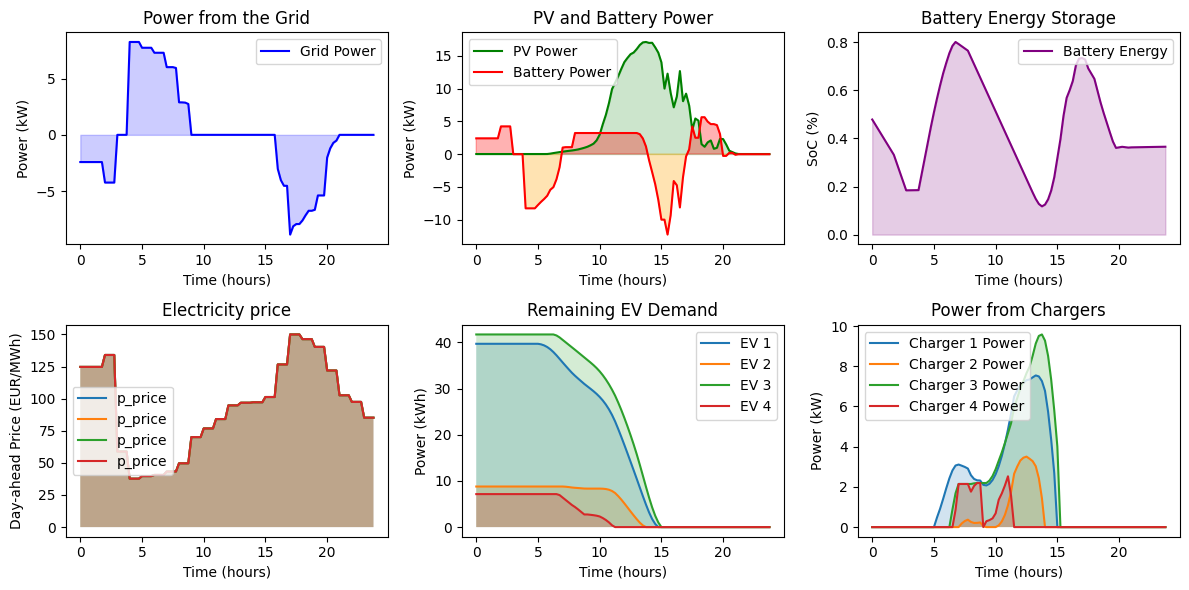

In [25]:
# Example usage:
# Parameters
num_time_steps = 24*4  # 24 hours * 4 (15-minute resolution)
num_chargers = 4

ev_demand_initial = ev_demand_initial_sample.reshape(1,4) # Example EV demand
storage_energy_initial = np.array([storage_capacity]) / 2

# Storage constraints
storage_capacity = 30  # Example capacity
capacity_high_imit = 0.8
capacity_low_imit = 0.2

current_time = 0
time_shift = 1

results = {
    'p_grid':           np.zeros((1,)),
    'p_grid_positive':  np.zeros((1,)),
    'p_grid_negative':  np.zeros((1,)),
    'p_storage':        np.zeros((1,)),
    'storage_energy':   storage_energy_initial,
    'ideal_storage_energy': storage_energy_initial,
    'p_chargers':       np.zeros((1, num_chargers)),
    'remaining_demand': ev_demand_initial,
}

num_chargers=4
time_resolution=0.25
storage_capacity=30     
capacity_high_limit=0.85
capacity_low_limit=0.2
p_storage_limit=14
p_charger_limit=11

for t in range(1, num_time_steps+1, time_shift):
    p_pv = expanded_pv[t]/ 1000  # PV power generation over time
    charger_availability = charger_availability_data[t, :num_chargers]  # Charger availability
    p_price = expanded_price[t]

    p_chargers_exec = p_chargers.value[t]
    p_grid_exec  = p_grid.value[t]
    p_storage_exec  = p_storage.value[t]
    # print(p_pv.shape, charger_availability.shape, p_price.shape, p_pv)

    # apply dynamics of storage and demands
    storage_energy_sample = results['storage_energy'][-1] - (1/0.95)*np.maximum(0, p_storage_exec)*time_resolution -\
                                                            (0.95)*np.minimum(0, p_storage_exec)*time_resolution
    ideal_storage_energy_sample = results['ideal_storage_energy'][-1] - np.maximum(0, p_storage_exec)*time_resolution -\
                                                            np.minimum(0, p_storage_exec)*time_resolution
    
    ev_demand_sample = results['remaining_demand'][-1] - p_chargers_exec*time_resolution
    
    # Store results
    results['p_grid'] = np.hstack([results['p_grid'], p_grid_exec])

    results['p_storage'] = np.hstack([results['p_storage'], p_storage_exec])
    results['p_chargers'] = np.vstack([results['p_chargers'], p_chargers_exec])
    results['storage_energy'] = np.hstack([results['storage_energy'], storage_energy_sample])
    results['ideal_storage_energy'] = np.hstack([results['ideal_storage_energy'], ideal_storage_energy_sample])
    results['remaining_demand'] = np.vstack([results['remaining_demand'], ev_demand_sample])
    
    # if t == 4*time_shift+1:
    #     break

for key in results.keys():
    if key not in ['storage_energy', 'remaining_demand']:
        results[key] = results[key][1:]
    else:
        results[key] = results[key][1:]

plt.figure(figsize=(12, 6))
time_steps = np.arange(len(results['p_grid'])) / 4  # Scale the time steps to hours

# Plot grid power
plt.subplot(2, 3, 1)
plt.plot(time_steps, results['p_grid'], label='Grid Power', color='blue')
plt.fill_between(time_steps, 0, results['p_grid'], color='blue', alpha=0.2)
plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('Power from the Grid')
plt.legend()

# Plot PV power and battery power
plt.subplot(2, 3, 2)
plt.plot(time_steps, expanded_pv[1:1+len(time_steps)]/1000, label='PV Power', color='green')
plt.fill_between(time_steps, 0, expanded_pv[1:1+len(time_steps)]/1000, color='green', alpha=0.2)
plt.plot(time_steps, results['p_storage'], label='Battery Power', color='red')
plt.fill_between(time_steps, 0, results['p_storage'], where=np.array(results['p_storage']) >= 0, color='red', alpha=0.3, interpolate=True)
plt.fill_between(time_steps, 0, results['p_storage'], where=np.array(results['p_storage']) < 0, color='orange', alpha=0.3, interpolate=True)
plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('PV and Battery Power')
plt.legend()

# Plot battery energy
plt.subplot(2, 3, 3)
plt.plot(time_steps, np.array(results['storage_energy'])/storage_capacity, label='Battery Energy', color='purple')
plt.fill_between(time_steps, 0, np.array(results['storage_energy'])/storage_capacity, color='purple', alpha=0.2)
plt.xlabel('Time (hours)')
plt.ylabel('SoC (%)')
plt.title('Battery Energy Storage')
plt.legend()

# Plot electricity price
plt.subplot(2, 3, 4)
for i in range(4):
    plt.plot(time_steps, expanded_price[1:1+len(time_steps)], label=f'p_price')
    plt.fill_between(time_steps, 0, expanded_price[1:1+len(time_steps)], alpha=0.2)
plt.xlabel('Time (hours)')
plt.ylabel('Day-ahead Price (EUR/MWh)')
plt.title('Electricity price')
plt.legend()

# Plot EV demand
plt.subplot(2, 3, 5)
for i in range(4):
    plt.plot(time_steps, results['remaining_demand'][:,i], label=f'EV {i+1}')
    plt.fill_between(time_steps, 0, results['remaining_demand'][:,i], alpha=0.2)
plt.xlabel('Time (hours)')
plt.ylabel('Power (kWh)')
plt.title('Remaining EV Demand')
plt.legend()

# Plot charger power
plt.subplot(2, 3, 6)
for i in range(4):
    plt.plot(time_steps, results['p_chargers'][:,i], label=f'Charger {i+1} Power')
    plt.fill_between(time_steps, 0, results['p_chargers'][:,i], alpha=0.2)
plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('Power from Chargers')
plt.legend()

plt.tight_layout()
plt.show()

In [26]:
ideal = np.array(results['ideal_storage_energy'])/storage_capacity
one_time = np.array(results['storage_energy'])/storage_capacity

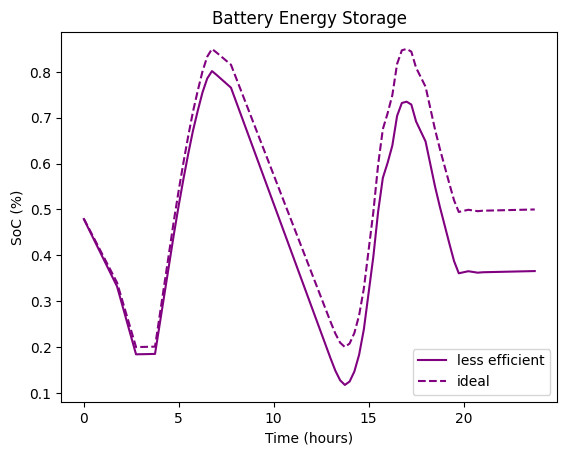

In [27]:
plt.plot(time_steps, np.array(results['storage_energy'])/storage_capacity, label='less efficient', color='purple')
plt.plot(time_steps, np.array(results['ideal_storage_energy'])/storage_capacity, '--', label='ideal', color='purple')

# plt.fill_between(time_steps, 0, np.array(results['storage_energy'])/storage_capacity, color='purple', alpha=0.2)
plt.xlabel('Time (hours)')
plt.ylabel('SoC (%)')
plt.title('Battery Energy Storage')
plt.legend()

In [28]:
np.sum(np.maximum(0, p_grid.value[1:])*expanded_price[1:1+len(time_steps)])

5268.326776752848

In [29]:
np.sum(np.maximum(0, -p_grid.value[1:])*expanded_price[1:1+len(time_steps)]/2)

9775.523346647275

In [30]:
dev_power = storage_capacity/2-np.array(results['storage_energy'])[-1]
np.sum(np.maximum(0, p_grid.value[1:])*expanded_price[1:1+len(time_steps)] -\
        np.maximum(0, -p_grid.value[1:])*expanded_price[1:1+len(time_steps)]/2) +\
        np.maximum(0, dev_power)*expanded_price.max()*4 -\
        np.maximum(0, -dev_power)*expanded_price.max()/2*4

-2090.404558316737

In [31]:
dev_power

4.028792444451705

In [32]:
# np.sum(np.abs(p_grid.value[1:])*co2_repeated)/4

In [33]:
p_grid_one_time = results['p_grid']

# sliding window

(97,) (4,) (97, 4) 15.0
(89,) (4,) (89, 4) 9.964714050291722
(81,) (4,) (81, 4) 5.791330839458331
(73,) (4,) (73, 4) 19.875884821539923
(65,) (4,) (65, 4) 22.953392137475927
(57,) (4,) (57, 4) 16.868295909096986
(49,) (4,) (49, 4) 10.835646943262486
(41,) (4,) (41, 4) 5.74549226614408
(33,) (4,) (33, 4) 17.15294543774588
(25,) (4,) (25, 4) 22.073060419081045
(17,) (4,) (17, 4) 14.073723660264761
(9,) (4,) (9, 4) 14.953686183013238


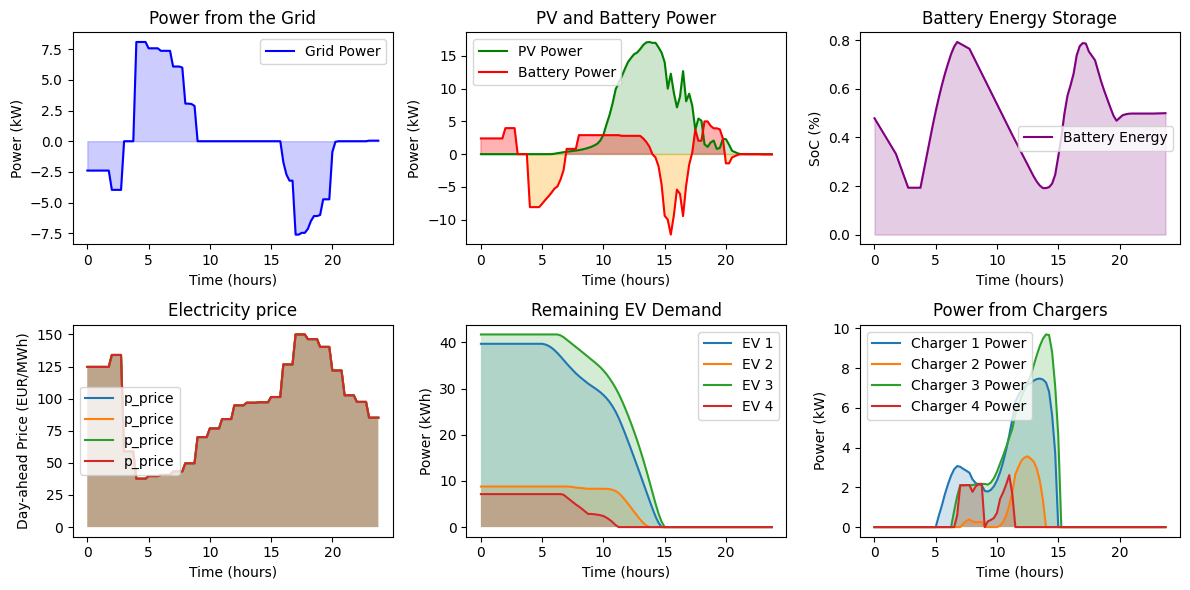

In [34]:
import cvxpy as cp
import numpy as np

class MPC:
    def __init__(self, num_chargers=4, time_resolution=0.25, storage_capacity=30,
                 capacity_high_limit=0.8, capacity_low_limit=0.2, p_storage_limit=14, p_charger_limit=11):
        self.num_chargers = num_chargers
        self.time_resolution = time_resolution
        self.storage_capacity = storage_capacity
        self.capacity_high_limit = capacity_high_limit
        self.capacity_low_limit = capacity_low_limit
        self.p_storage_limit = p_storage_limit
        self.p_charger_limit = p_charger_limit

        # 2 hours * resolution
        self.time_shift = 2 * int(1 / self.time_resolution)  
        # Big-M constant
        self.M = 1e5

    def step(self, p_pv, results, charger_availability, p_price):
        self.num_time_steps = len(p_pv)  # 24 hours * resolution

        # Initialize parameters
        self.p_grid_initial = cp.Parameter(1, value=results['p_grid'][-1:])
        self.p_grid_positive_initial = cp.Parameter(1, nonneg=True, value=np.clip(results['p_grid_positive'][-1:], 0, np.inf))
        self.p_grid_negative_initial = cp.Parameter(1, nonneg=True, value=np.clip(results['p_grid_negative'][-1:], 0, np.inf))

        self.p_storage_initial = cp.Parameter(1, value=np.clip(results['p_storage'][-1:], -self.p_storage_limit, self.p_storage_limit))
        self.p_chargers_initial = cp.Parameter(self.num_chargers, nonneg=True, value=np.clip(results['p_chargers'][-1,:], 0, self.p_charger_limit))
        self.storage_energy_initial = cp.Parameter(1, nonneg=True, value=np.clip(results['storage_energy'][-1:], 
                                                                                 self.storage_capacity*self.capacity_low_limit, 
                                                                                 self.storage_capacity*self.capacity_high_limit))

        self.ev_demand = cp.Parameter(self.num_chargers, nonneg=True, value=np.clip(results['remaining_demand'][-1,:], 0, np.inf))
        self.charger_availability = cp.Parameter((self.num_time_steps, self.num_chargers), boolean=True, value=charger_availability)
        self.p_price = cp.Parameter(self.num_time_steps, value=p_price)

        # Initialize decision variables
        self.p_chargers = cp.Variable((self.num_time_steps, self.num_chargers), nonneg=True)
        self.p_grid = cp.Variable(self.num_time_steps)
        self.p_grid_positive = cp.Variable(self.num_time_steps, nonneg=True)
        self.p_grid_negative = cp.Variable(self.num_time_steps, nonneg=True)
        self.p_storage = cp.Variable(self.num_time_steps)
        self.storage_energy = cp.Variable(self.num_time_steps, nonneg=True)

        # Binary variables for big-M method
        self.binary_pos = cp.Variable(self.num_time_steps, boolean=True)

        # Constraints
        constraints = []

        # Charger availability constraints
        constraints.append(self.p_chargers <= charger_availability*self.p_charger_limit)

        # Power balance constraints
        constraints.append(p_pv + self.p_grid + self.p_storage == cp.sum(self.p_chargers, axis=1))

        # Storage constraints
        constraints.append(self.storage_energy <= self.storage_capacity * self.capacity_high_limit)
        constraints.append(self.storage_energy >= self.storage_capacity * self.capacity_low_limit)
        constraints.append(self.p_storage <= self.p_storage_limit)
        constraints.append(self.p_storage >= -self.p_storage_limit)

        # Initial conditions
        # constraints.append(self.p_grid[0] == self.p_grid_initial)
        constraints.append(self.p_grid_positive[0] == self.p_grid_positive_initial)
        constraints.append(self.p_grid_negative[0] == self.p_grid_negative_initial)

        constraints.append(self.p_storage[0] == self.p_storage_initial)
        constraints.append(self.p_chargers[0] == self.p_chargers_initial)
        constraints.append(self.storage_energy[0] == self.storage_energy_initial)
        constraints.append(self.storage_energy[-1] == self.storage_capacity/2)

        # Storage dynamics
        constraints.append(self.storage_energy[1:] == self.storage_energy[:-1] - self.p_storage[1:]*self.time_resolution)

        # EV demand constraints
        constraints.append(cp.sum(self.p_chargers[1:]*self.time_resolution, axis=0) == self.ev_demand)

        # Auxiliary variables constraints
        constraints.append(self.p_grid == self.p_grid_positive - self.p_grid_negative)

        # Ensure p_grid_positive and p_grid_negative cannot be positive at the same time
        constraints.append(self.binary_pos <= 1)
        constraints.append(self.p_grid_positive <= self.binary_pos * self.M)
        constraints.append(self.p_grid_negative <= (1-self.binary_pos) * self.M)

        # Smoothing constraint to avoid abrupt changes: total variations
        smoothing_penalty = cp.tv(self.p_grid_positive) + cp.tv(self.p_grid_negative) + cp.tv(self.p_storage) + 2*cp.tv(self.p_chargers) 

        # Objective: Minimize total grid power usage
        objective = cp.Minimize(cp.sum(self.p_grid**2) 
                                + cp.sum(cp.multiply(self.p_price,self.p_grid_positive))
                                - cp.sum(cp.multiply(self.p_price/2,self.p_grid_negative))
                                + smoothing_penalty)

        # Problem definition and solving
        problem = cp.Problem(objective, constraints)
        problem.solve(solver=cp.SCIP)
        
        # Output the results
        if problem.status not in ["infeasible", "unbounded"]:
            return {
                "status": problem.status,
                "objective_value": objective.value,
                "p_grid": np.array(self.p_grid.value)[1:1+self.time_shift],
                "p_grid_positive": np.array(self.p_grid_positive.value)[1:1+self.time_shift],
                "p_grid_negative": np.array(self.p_grid_negative.value)[1:1+self.time_shift],
                "p_chargers": np.array(self.p_chargers.value)[1:1+self.time_shift,:],
                "p_storage": np.array(self.p_storage.value)[1:1+self.time_shift],
            }
        else:
            print("The problem is infeasible or unbounded.")

# Example usage:
# Parameters
num_time_steps = 24*4  # 24 hours * 4 (15-minute resolution)
num_chargers = 4

ev_demand_initial = ev_demand_initial_sample.reshape(1,4) # Example EV demand
storage_energy_initial = np.array([storage_capacity]) / 2

# Storage constraints
storage_capacity = 30  # Example capacity
capacity_high_imit = 0.8
capacity_low_imit = 0.2

mpc = MPC()
current_time = 0
time_shift = 2 * int(1 / mpc.time_resolution)  # 2 hours * resolution

results = {
    'p_grid':           np.zeros((1,)),
    'p_grid_positive':  np.zeros((1,)),
    'p_grid_negative':  np.zeros((1,)),
    'p_storage':        np.zeros((1,)),
    'storage_energy':   storage_energy_initial,
    'p_chargers':       np.zeros((1, num_chargers)),
    'remaining_demand': ev_demand_initial,
}

for t in range(1, num_time_steps, time_shift):
    p_pv = expanded_pv[t-1:]/ 1000  # PV power generation over time
    charger_availability = charger_availability_data[t-1:, :mpc.num_chargers]  # Charger availability
    p_price = expanded_price[t-1:]

    print(p_pv.shape, results['remaining_demand'][-1,:].shape, charger_availability.shape, results['storage_energy'][-1])
    command = mpc.step(p_pv, results, charger_availability, p_price)

    # apply dynamics of storage and demands
    storage_energy_samples = results['storage_energy'][-1] - (1/0.95)*np.cumsum(np.maximum(0, command['p_storage']))*mpc.time_resolution -\
                                                             (0.95) * np.cumsum(np.minimum(0, command['p_storage']))*time_resolution
    ev_demand_samples = results['remaining_demand'][-1].reshape(1,4) - np.cumsum(command['p_chargers'], axis=0)*mpc.time_resolution
    
    # Store results
    results['p_grid'] = np.hstack([results['p_grid'], command['p_grid']])
    results['p_grid_positive'] = np.hstack([results['p_grid_positive'], command['p_grid_positive']])
    results['p_grid_negative'] = np.hstack([results['p_grid_negative'], command['p_grid_negative']])

    results['p_storage'] = np.hstack([results['p_storage'], command['p_storage']])
    results['p_chargers'] = np.vstack([results['p_chargers'], command['p_chargers']])
    results['storage_energy'] = np.hstack([results['storage_energy'], storage_energy_samples])
    results['remaining_demand'] = np.vstack([results['remaining_demand'], ev_demand_samples])
    
    # if t == 4*time_shift+1:
    #     break

for key in results.keys():
    if key not in ['storage_energy', 'remaining_demand']:
        results[key] = results[key][1:]
    else:
        results[key] = results[key][1:]
        
plt.figure(figsize=(12, 6))
time_steps = np.arange(len(results['p_grid'])) / 4  # Scale the time steps to hours

# Plot grid power
plt.subplot(2, 3, 1)
plt.plot(time_steps, results['p_grid'], label='Grid Power', color='blue')
plt.fill_between(time_steps, 0, results['p_grid'], color='blue', alpha=0.2)
plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('Power from the Grid')
plt.legend()

# Plot PV power and battery power
plt.subplot(2, 3, 2)
plt.plot(time_steps, expanded_pv[1:1+len(time_steps)]/1000, label='PV Power', color='green')
plt.fill_between(time_steps, 0, expanded_pv[1:1+len(time_steps)]/1000, color='green', alpha=0.2)
plt.plot(time_steps, results['p_storage'], label='Battery Power', color='red')
plt.fill_between(time_steps, 0, results['p_storage'], where=np.array(results['p_storage']) >= 0, color='red', alpha=0.3, interpolate=True)
plt.fill_between(time_steps, 0, results['p_storage'], where=np.array(results['p_storage']) < 0, color='orange', alpha=0.3, interpolate=True)
plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('PV and Battery Power')
plt.legend()

# Plot battery energy
plt.subplot(2, 3, 3)
plt.plot(time_steps, np.array(results['storage_energy'])/storage_capacity, label='Battery Energy', color='purple')
plt.fill_between(time_steps, 0, np.array(results['storage_energy'])/storage_capacity, color='purple', alpha=0.2)
plt.xlabel('Time (hours)')
plt.ylabel('SoC (%)')
plt.title('Battery Energy Storage')
plt.legend()

# Plot electricity price
plt.subplot(2, 3, 4)
for i in range(4):
    plt.plot(time_steps, expanded_price[1:1+len(time_steps)], label=f'p_price')
    plt.fill_between(time_steps, 0, expanded_price[1:1+len(time_steps)], alpha=0.2)
plt.xlabel('Time (hours)')
plt.ylabel('Day-ahead Price (EUR/MWh)')
plt.title('Electricity price')
plt.legend()

# Plot EV demand
plt.subplot(2, 3, 5)
for i in range(4):
    plt.plot(time_steps, results['remaining_demand'][:,i], label=f'EV {i+1}')
    plt.fill_between(time_steps, 0, results['remaining_demand'][:,i], alpha=0.2)
plt.xlabel('Time (hours)')
plt.ylabel('Power (kWh)')
plt.title('Remaining EV Demand')
plt.legend()

# Plot charger power
plt.subplot(2, 3, 6)
for i in range(4):
    plt.plot(time_steps, results['p_chargers'][:,i], label=f'Charger {i+1} Power')
    plt.fill_between(time_steps, 0, results['p_chargers'][:,i], alpha=0.2)
plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('Power from Chargers')
plt.legend()

plt.tight_layout()
plt.show()

In [35]:
shrinking = np.array(results['storage_energy'])/storage_capacity

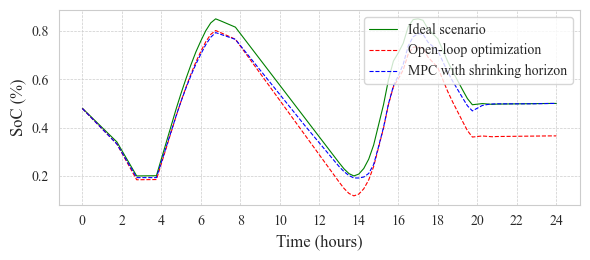

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
# Set font to Times New Roman
plt.rcParams['font.family'] = 'Times New Roman'

ideal_n = np.hstack([ideal, ideal[-1]])
one_time_n = np.hstack([one_time, one_time[-1]])
shrinking_n = np.hstack([shrinking, shrinking[-1]])
time_steps_n = np.hstack([time_steps, 24])

plt.figure(figsize=(6, 2.7))
plt.plot(time_steps_n, ideal_n, label='Ideal scenario', color='green', linewidth=0.8)
plt.plot(time_steps_n, one_time_n, '--', label='Open-loop optimization', color='red', linewidth=0.8)
plt.plot(time_steps_n, shrinking_n, '--', label='MPC with shrinking horizon', color='blue', linewidth=0.8)
plt.xticks(np.arange(0,25, 2))
# plt.fill_between(time_steps, 0, np.array(results['storage_energy'])/storage_capacity, color='purple', alpha=0.2)
plt.xlabel('Time (hours)', fontsize=12)
plt.ylabel('SoC (%)', fontsize=12)
# plt.title('Battery Energy Storage')
plt.legend(loc='upper right')

plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.savefig('unmodeled.png', dpi=300, bbox_inches='tight', pad_inches=0.05)  # Save with 300 DPI


In [37]:
ideal_n[-1], one_time_n[-1], shrinking_n[-1]

(0.5000000000000002, 0.3657069185182765, 0.49992281030502206)

In [38]:
ideal_n[-1] - one_time_n[-1]

0.1342930814817237

In [39]:
ideal_n[-1] - shrinking_n[-1]

7.718969497816364e-05

In [40]:
0.5- one_time_n[-1]/1

0.13429308148172348

In [41]:
0.5-shrinking_n[-1]/1

7.718969497794159e-05

In [42]:
0.12832982959937667 - 0.01660441286429748

0.11172541673507919

## visualize the results

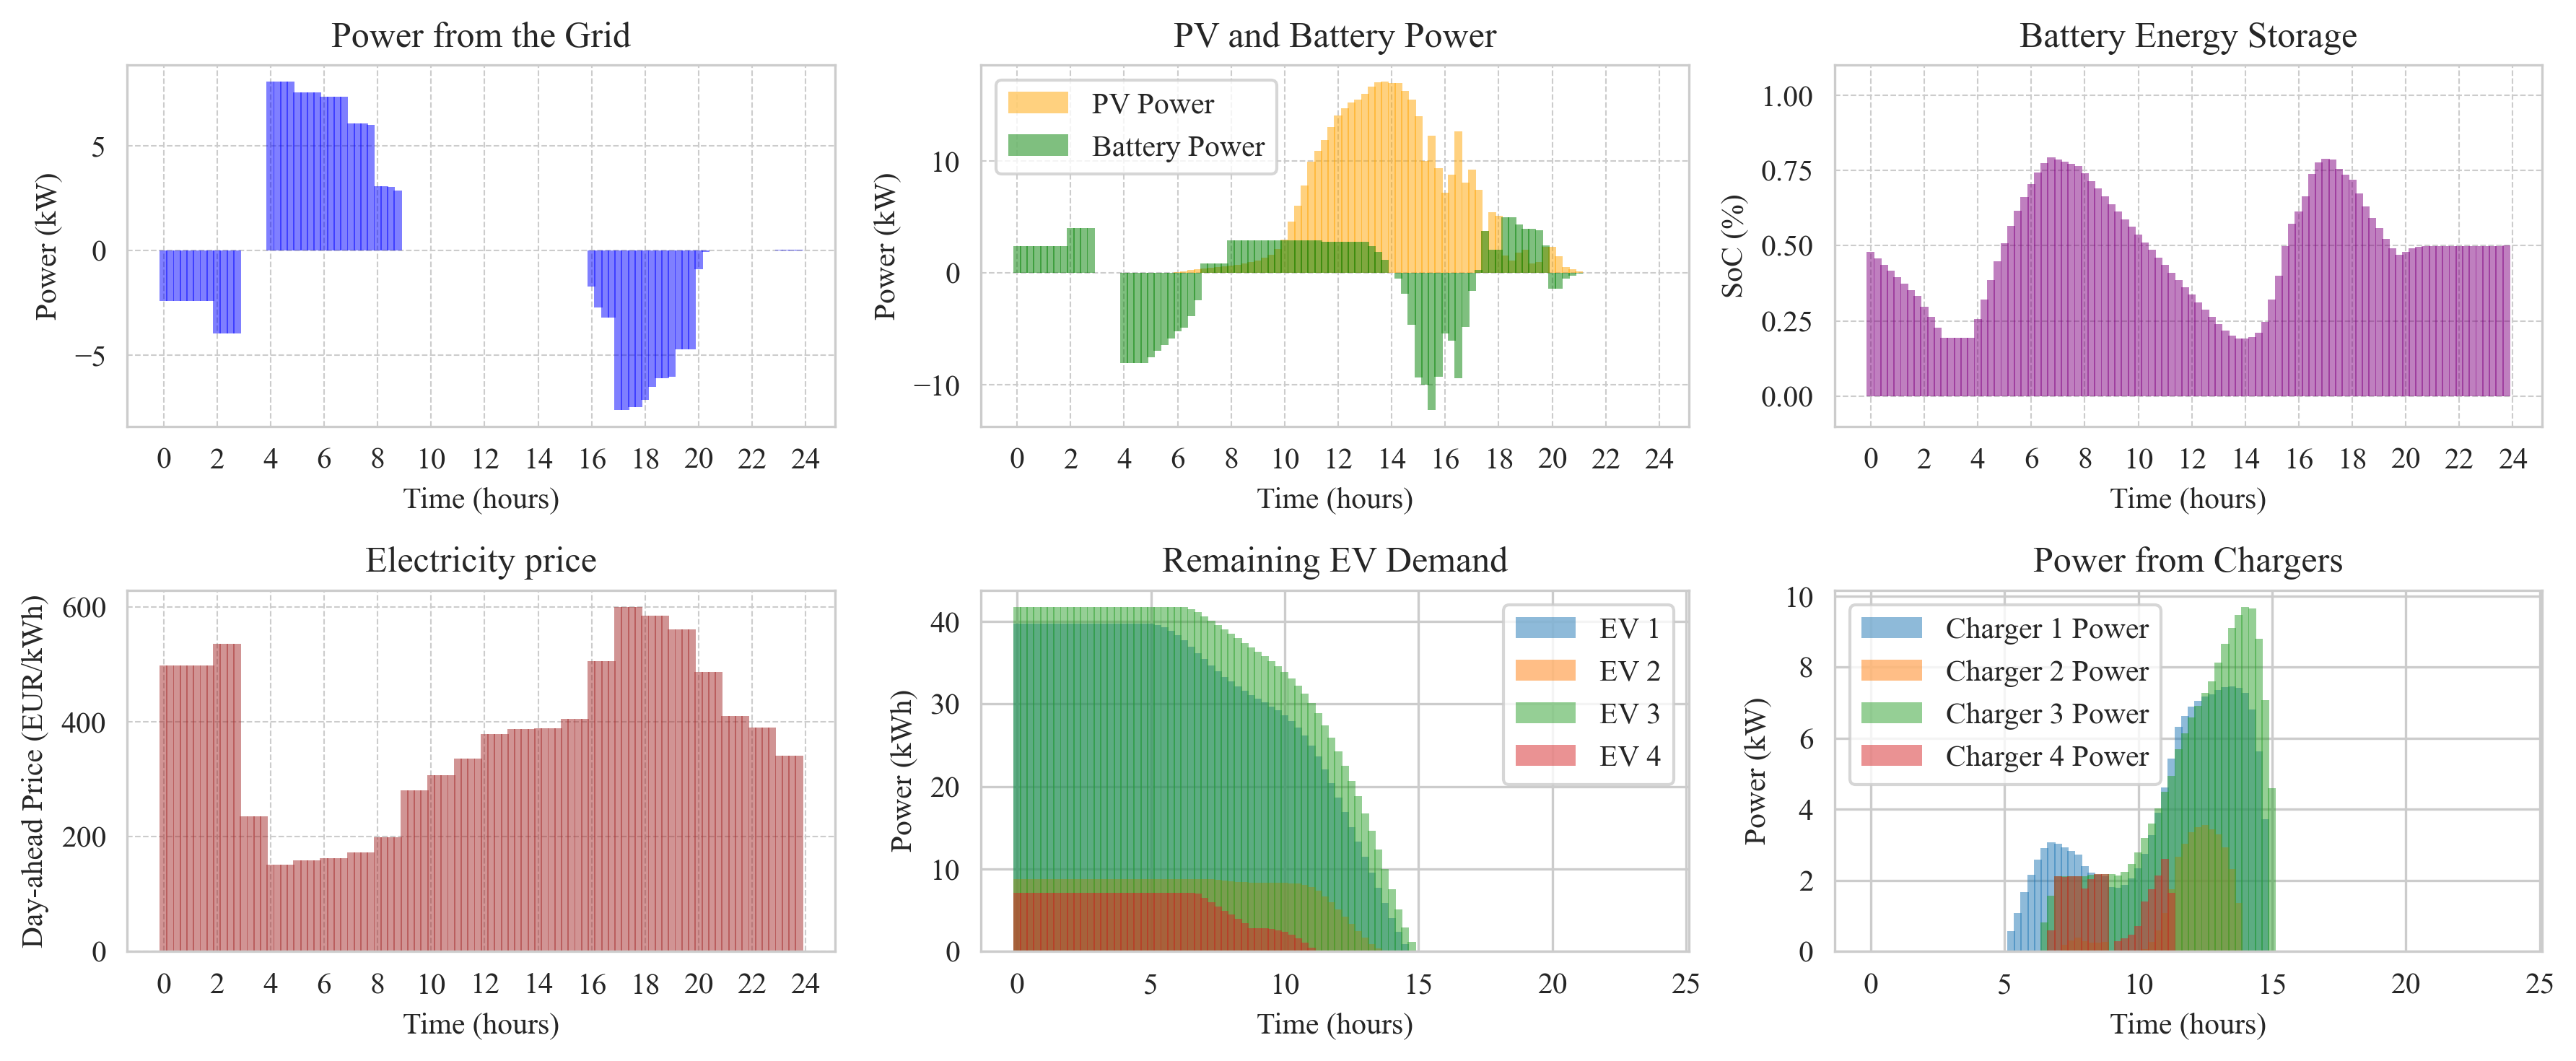

In [43]:
# Set font to Times New Roman
plt.rcParams['font.family'] = 'Times New Roman'
    
plt.figure(figsize=(12, 5), dpi=300)
time_steps = np.arange(len(results['p_grid'])) / 4  # Scale the time steps to hours
hours = np.arange(0, 25, 2)  # Hours from 1 to 24

# Plot grid power
plt.subplot(2, 3, 1)
plt.bar(time_steps, results['p_grid'], label='Grid Power', color='blue', alpha=0.5, width=0.3, edgecolor='none')
plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('Power from the Grid')
plt.xticks(hours)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Plot PV power and battery power
plt.subplot(2, 3, 2)
plt.bar(time_steps, expanded_pv[1:1+len(time_steps)]/1000, label='PV Power', color='orange', alpha=0.5, width=0.3, edgecolor='none')
plt.bar(time_steps, results['p_storage'], label='Battery Power', color='green', alpha=0.5, width=0.3, edgecolor='none')
plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('PV and Battery Power')
plt.legend(loc='upper left')
plt.xticks(hours)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)


# Plot battery energy
plt.subplot(2, 3, 3)
plt.bar(time_steps, np.array(results['storage_energy'])/storage_capacity, label='Battery Energy', color='purple', alpha=0.5, width=0.3, edgecolor='none')
plt.xlabel('Time (hours)')
plt.ylabel('SoC (%)')
plt.title('Battery Energy Storage')
plt.xticks(hours)
plt.ylim([-0.1,1.1])
plt.grid(True, which='both', linestyle='--', linewidth=0.5)


# Plot electricity price
plt.subplot(2, 3, 4)
plt.bar(time_steps, expanded_price[1:1+len(time_steps)]*4, label=f'p_price', color='brown', alpha=0.5, width=0.3, edgecolor='none')
plt.xlabel('Time (hours)')
plt.ylabel('Day-ahead Price (EUR/kWh)')
plt.title('Electricity price')
plt.xticks(hours)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)


# Plot EV demand
plt.subplot(2, 3, 5)
for i in range(4):
    plt.bar(time_steps, results['remaining_demand'][:,i], label=f'EV {i+1}', alpha=0.5, width=0.3, edgecolor='none')
plt.xlabel('Time (hours)')
plt.ylabel('Power (kWh)')
plt.title('Remaining EV Demand')
plt.legend()

# Plot charger power
plt.subplot(2, 3, 6)
for i in range(4):
    plt.bar(time_steps, results['p_chargers'][:,i], label=f'Charger {i+1} Power', alpha=0.5, width=0.3, edgecolor='none')
plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('Power from Chargers')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

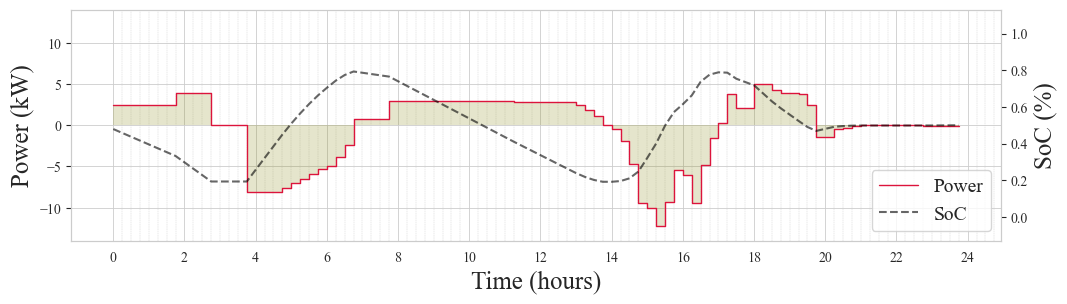

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'Times New Roman'

# Create figure and first set of axes
fig, ax1 = plt.subplots(figsize=(12, 3))

# Plot for ax1 (Battery Power)
plt.fill_between(time_steps, results['p_storage'], label='Power', color='olive', alpha=0.2, edgecolor='None', step="pre")
line1, = ax1.plot(time_steps, results['p_storage'], color='crimson', linewidth=1, drawstyle='steps', label='Power')

ax1.set_xlabel('Time (hours)', size=18)
ax1.set_ylabel('Power (kW)', size=18)
ax1.set_ylim([-14, 14])
ax1.grid(True, which='minor', linestyle='--', linewidth=0.3)
ax1.grid(True, which='major', linestyle='-', linewidth=0.6)

# Set x-axis ticks
minor_hours = np.arange(0, 25, 0.25)
major_hours = np.arange(0, 25, 2)
plt.xticks(minor_hours, minor=True)
plt.xticks(major_hours, minor=False)

# Create second y-axis
ax2 = ax1.twinx()

# Plot for ax2 (Storage SoC)
line2, = ax2.plot(time_steps, np.array(results['storage_energy']) / storage_capacity, '--', label='SoC', color='black', alpha=0.6, linewidth=1.5)

ax2.set_ylabel('SoC (%)', size=18)
ax2.set_ylim([-0.13, 1.13])
ax2.grid(False)

# Combine legends from both axes
lines = [line1, line2]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='lower right', fontsize=14)

# Save the figure
plt.savefig('res_storage.png', dpi=300, bbox_inches='tight', pad_inches=0)


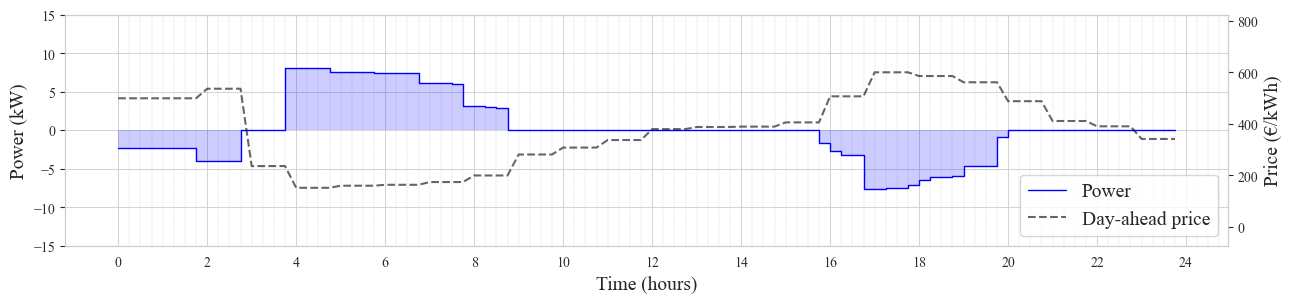

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'Times New Roman'

# Create figure and first set of axes
fig, ax1 = plt.subplots(figsize=(15, 3))

# Plot for ax1 (Grid Power)
plt.fill_between(time_steps, results['p_grid'], label='Power', color='blue', alpha=0.2, edgecolor='None', step="pre")
line1, = ax1.plot(time_steps, results['p_grid'], color='blue', linewidth=1, drawstyle='steps', label='Power')

ax1.set_xlabel('Time (hours)', size=14)
ax1.set_ylabel('Power (kW)', size=14)
ax1.set_ylim([-15,15])
ax1.grid(True, which='minor', linestyle='--', linewidth=0.3)
ax1.grid(True, which='major', linestyle='-', linewidth=0.6)

# Set x-axis ticks
minor_hours = np.arange(0, 25, 0.25)
major_hours = np.arange(0, 25, 2)
plt.xticks(minor_hours, minor=True)
plt.xticks(major_hours, minor=False)

# Create second y-axis
ax2 = ax1.twinx()

# Plot for ax2 (Price)
line2, = ax2.plot(time_steps, expanded_price[1:1+len(time_steps)]*4, '--', label='Day-ahead price', color='black', alpha=0.6, linewidth=1.5)
ax2.set_ylabel('Price (€/kWh)', size=14)
price_span = expanded_price[1:1+len(time_steps)].max()*4-expanded_price[1:1+len(time_steps)].min()*4
plt.ylim([expanded_price[1:1+len(time_steps)].min()*4-price_span/2,expanded_price[1:1+len(time_steps)].max()*4+price_span/2+0.012])
ax2.grid(False)

# Combine legends from both axes
lines = [line1, line2]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='lower right', fontsize=14)

# Save the figure
plt.savefig('res_grid.png', dpi=300, bbox_inches='tight', pad_inches=0)


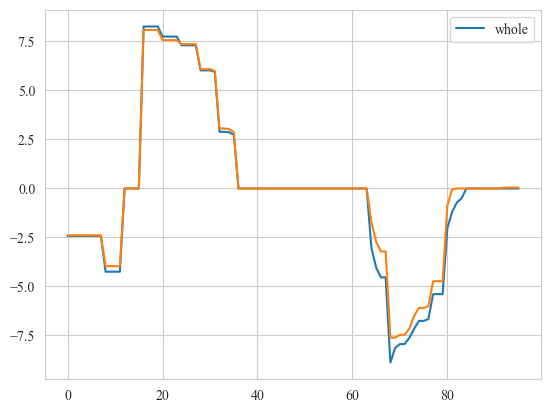

In [46]:
plt.plot(p_grid.value[1:], label='whole')
plt.plot(results['p_grid'])
plt.legend()

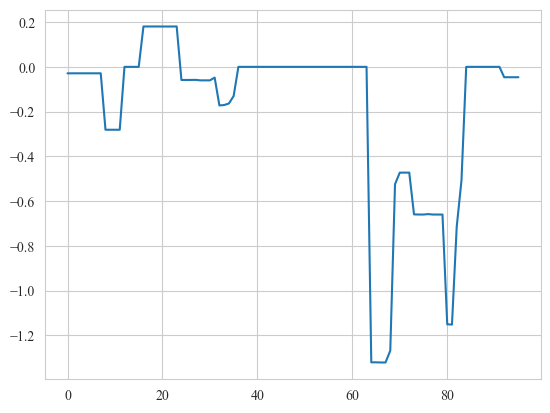

In [47]:
plt.plot(p_grid.value[1:] - results['p_grid'])

In [48]:
np.sum(np.maximum(0, results['p_grid'])*expanded_price[1:1+len(time_steps)] - np.maximum(0, -results['p_grid'])*expanded_price[1:1+len(time_steps)]/2)

-3287.730885040778

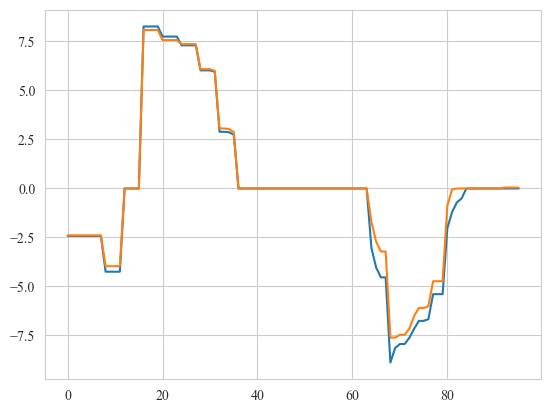

In [49]:
plt.plot(p_grid_one_time)
plt.plot(results['p_grid'])

# plt.ylim([-0.2,0])

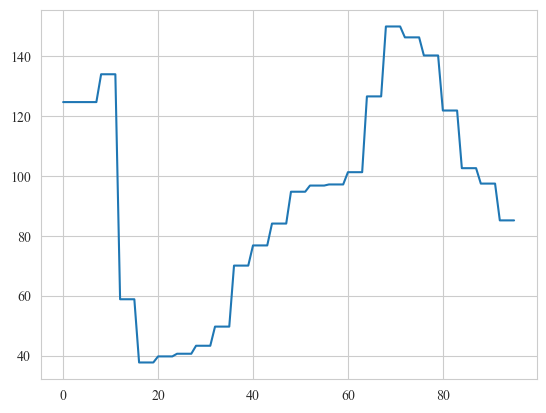

In [50]:
plt.plot(expanded_price[1:])

In [51]:
np.sum(np.maximum(0, p_grid_one_time)*expanded_price[1:1+len(time_steps)]), np.sum(np.maximum(0, results['p_grid'])*expanded_price[1:1+len(time_steps)])

(5268.326776752848, 5279.288617698001)

In [52]:
results['storage_energy']

array([14.37062154, 13.74120618, 13.11179083, 12.48237547, 11.85296012,
       11.22354476, 10.59412941,  9.96471405,  8.92136825,  7.87802244,
        6.83467664,  5.79133084,  5.79133084,  5.79133084,  5.79133084,
        5.79133084,  7.71163868,  9.63194652, 11.55225436, 13.4725622 ,
       15.27056467, 16.93216669, 18.47212895, 19.87588482, 21.12788042,
       22.29686465, 23.21494232, 23.79379424, 23.58369372, 23.37359319,
       23.16349266, 22.95339214, 22.19275511, 21.43211808, 20.67148105,
       19.91084402, 19.15020699, 18.38956997, 17.62893294, 16.86829591,
       16.10765888, 15.34702185, 14.58638482, 13.8257478 , 13.06511077,
       12.30447374, 11.57006034, 10.83564694, 10.10123355,  9.36682015,
        8.63240675,  7.89799335,  7.16625514,  6.53701726,  6.04823773,
        5.74549227,  5.74549221,  5.864968  ,  6.30763855,  7.41517932,
        9.64853911, 12.02145441, 14.9362893 , 17.15294544, 18.4390506 ,
       19.87881353, 22.12357368, 23.27601327, 23.65764727, 23.60

In [53]:
np.array(results['storage_energy'])

array([14.37062154, 13.74120618, 13.11179083, 12.48237547, 11.85296012,
       11.22354476, 10.59412941,  9.96471405,  8.92136825,  7.87802244,
        6.83467664,  5.79133084,  5.79133084,  5.79133084,  5.79133084,
        5.79133084,  7.71163868,  9.63194652, 11.55225436, 13.4725622 ,
       15.27056467, 16.93216669, 18.47212895, 19.87588482, 21.12788042,
       22.29686465, 23.21494232, 23.79379424, 23.58369372, 23.37359319,
       23.16349266, 22.95339214, 22.19275511, 21.43211808, 20.67148105,
       19.91084402, 19.15020699, 18.38956997, 17.62893294, 16.86829591,
       16.10765888, 15.34702185, 14.58638482, 13.8257478 , 13.06511077,
       12.30447374, 11.57006034, 10.83564694, 10.10123355,  9.36682015,
        8.63240675,  7.89799335,  7.16625514,  6.53701726,  6.04823773,
        5.74549227,  5.74549221,  5.864968  ,  6.30763855,  7.41517932,
        9.64853911, 12.02145441, 14.9362893 , 17.15294544, 18.4390506 ,
       19.87881353, 22.12357368, 23.27601327, 23.65764727, 23.60

In [54]:
(storage_capacity/2-np.array(results['storage_energy'])[-1]) * expanded_price[-1] *2 


0.3944084654592525

In [55]:
co2_df = pd.read_csv('data/CO2_2022.csv')
co2_df['validfrom (UTC)'] = pd.to_datetime(co2_df['validfrom (UTC)'])

# Extract year, month, day, and hour from the datetime
co2_df['Year'] =  co2_df['validfrom (UTC)'].dt.year
co2_df['Month'] = co2_df['validfrom (UTC)'].dt.month
co2_df['Day'] =   co2_df['validfrom (UTC)'].dt.day
co2_df['Hour'] =  co2_df['validfrom (UTC)'].dt.hour

# Select a specific day (e.g., January 1, 2022)
specific_day = co2_df[(co2_df['Year'] == 2022) & (co2_df['Month'] == 1) & (co2_df['Day'] == 1)]
co2_repeated = np.repeat(specific_day['emissionfactor (kg CO2/kWh)'], 4)


np.sum(np.abs(results['p_grid'])*co2_repeated)/4

14.723343285183827

In [56]:
co2_repeated

1     0.244775
1     0.244775
1     0.244775
1     0.244775
2     0.254986
        ...   
23    0.213921
24    0.208648
24    0.208648
24    0.208648
24    0.208648
Name: emissionfactor (kg CO2/kWh), Length: 96, dtype: float64

In [57]:
0.636515311428777/0.21212510344596902

3.0006599930352214

### p_chargers

In [58]:
ts = np.where(charger_availability_data[:,0]>0)
np.min(ts), np.max(ts)

(22, 60)

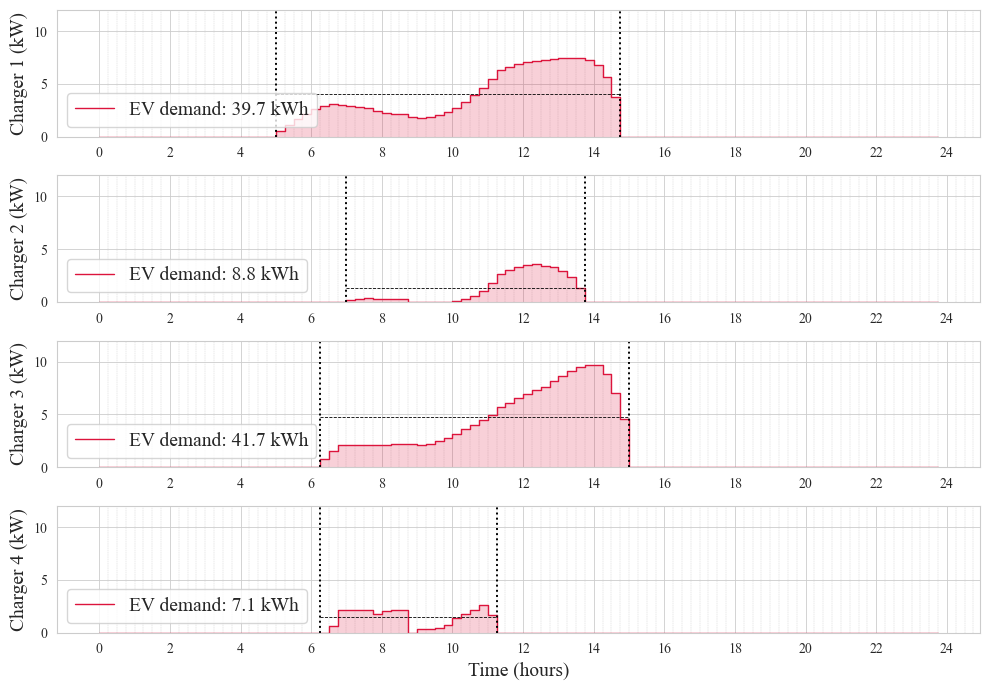

In [59]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'Times New Roman'

# Create figure and first set of axes
fig, axes = plt.subplots(4, 1, figsize=(10, 7))

for i in range(len(axes)):
    # Plot for ax1 (Battery Power)
    axes[i].fill_between(time_steps, results['p_chargers'][:,i], color='crimson', alpha=0.2, edgecolor='None', step="pre")
    line1, = axes[i].plot(time_steps, results['p_chargers'][:,i], color='crimson', linewidth=1, drawstyle='steps', label=f'EV demand: {ev_demand_initial[0,i]:.1f} kWh')

    ts = np.where(charger_availability_data[1:,i]>0)
    axes[i].axvline(x = (np.min(ts)-1)/4, color = 'black', linestyle=':', linewidth=1.4)
    axes[i].axvline(x = (np.max(ts))/4, color = 'black', linestyle=':', linewidth=1.4)

    charging_time = np.arange(np.min(ts)-1, np.max(ts)+1)/4
    axes[i].plot(charging_time, np.repeat(ev_demand_initial[0,i]/(max(charging_time)-min(charging_time)), len(charging_time)) , color = 'black', linestyle='--', linewidth=0.6)

    axes[i].set_ylabel(f'Charger {i+1} (kW)', size=14)
    axes[i].set_ylim([0, 12])
    axes[i].grid(True, which='minor', linestyle='--', linewidth=0.3)
    axes[i].grid(True, which='major', linestyle='-', linewidth=0.6)

    # Set x-axis ticks
    minor_hours = np.arange(0, 25, 0.25)
    major_hours = np.arange(0, 25, 2)
    axes[i].set_xticks(minor_hours, minor=True)
    axes[i].set_xticks(major_hours, minor=False)

    # # Combine legends from both axes
    axes[i].legend(loc='lower left', fontsize=14)

axes[i].set_xlabel('Time (hours)', size=14)
plt.tight_layout()
# Save the figure
plt.savefig('res_chargers.png', dpi=300, bbox_inches='tight', pad_inches=0.1)


In [60]:
ev_demand_initial[0,i]

7.1435547

In [61]:
np.repeat(ev_demand_initial[0,i]/10, len(charging_time))

array([0.71435547, 0.71435547, 0.71435547, 0.71435547, 0.71435547,
       0.71435547, 0.71435547, 0.71435547, 0.71435547, 0.71435547,
       0.71435547, 0.71435547, 0.71435547, 0.71435547, 0.71435547,
       0.71435547, 0.71435547, 0.71435547, 0.71435547, 0.71435547,
       0.71435547])

In [62]:
results['p_chargers'][:,0].shape

(96,)

In [63]:
ev_demand_initial[0].shape

(4,)

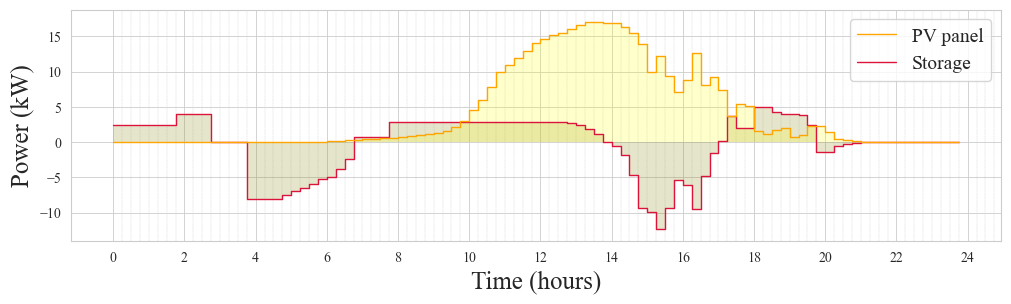

In [64]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'Times New Roman'

# Create figure and first set of axes
fig, ax1 = plt.subplots(figsize=(12, 3))

# Plot for ax1 (Battery Power)
ax1.fill_between(time_steps, results['p_storage'], label='Storage', color='olive', alpha=0.2, edgecolor='None', step="pre")
line1, = ax1.plot(time_steps, results['p_storage'], color='crimson', linewidth=1, drawstyle='steps', label='Storage')

ax1.set_xlabel('Time (hours)', size=18)
ax1.set_ylabel('Power (kW)', size=18)
ax1.set_ylim([-14, 18.8])
ax1.grid(True, which='minor', linestyle='--', linewidth=0.3)
ax1.grid(True, which='major', linestyle='-', linewidth=0.6)

# Set x-axis ticks
minor_hours = np.arange(0, 25, 0.25)
major_hours = np.arange(0, 25, 2)
plt.xticks(minor_hours, minor=True)
plt.xticks(major_hours, minor=False)


# Plot for ax2 (Storage SoC)
ax1.fill_between(time_steps, expanded_pv[1:]/1000, label='PV panel', color='yellow', alpha=0.2, edgecolor='None', step="pre")
line2, = ax1.plot(time_steps, expanded_pv[1:]/1000, color='orange', linewidth=1, drawstyle='steps', label='PV panel')
# line2, = ax2.plot(time_steps, p_pv, '--', label='SoC', color='orange', alpha=0.6, linewidth=1.5, drawstyle='steps')


# Combine legends from both axes
lines = [line2, line1]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='upper right', fontsize=14)

# Save the figure
plt.savefig('res_pv.png', dpi=300, bbox_inches='tight', pad_inches=0)


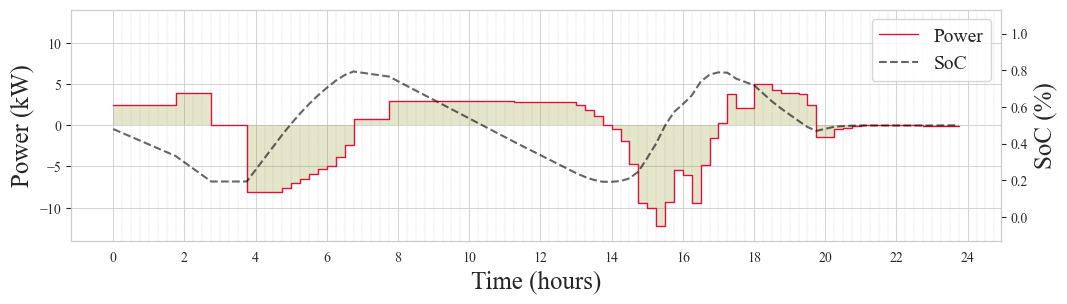

In [65]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'Times New Roman'

# Create figure and first set of axes
fig, ax1 = plt.subplots(figsize=(12, 3))

# Plot for ax1 (Battery Power)
plt.fill_between(time_steps, results['p_storage'], label='Power', color='olive', alpha=0.2, edgecolor='None', step="pre")
line1, = ax1.plot(time_steps, results['p_storage'], color='crimson', linewidth=1, drawstyle='steps', label='Power')

ax1.set_xlabel('Time (hours)', size=18)
ax1.set_ylabel('Power (kW)', size=18)
ax1.set_ylim([-14, 14])
ax1.grid(True, which='minor', linestyle='--', linewidth=0.3)
ax1.grid(True, which='major', linestyle='-', linewidth=0.6)

# Set x-axis ticks
minor_hours = np.arange(0, 25, 0.25)
major_hours = np.arange(0, 25, 2)
plt.xticks(minor_hours, minor=True)
plt.xticks(major_hours, minor=False)

# Create second y-axis
ax2 = ax1.twinx()

# Plot for ax2 (Storage SoC)
line2, = ax2.plot(time_steps, np.array(results['storage_energy']) / storage_capacity, '--', label='SoC', color='black', alpha=0.6, linewidth=1.5)

ax2.set_ylabel('SoC (%)', size=18)
ax2.set_ylim([-0.13, 1.13])
ax2.grid(False)

# Combine legends from both axes
lines = [line1, line2]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='upper right', fontsize=14)

# Save the figure
plt.savefig('res_storage.png', dpi=300, bbox_inches='tight', pad_inches=0)


# scalability

In [66]:
np.hstack([np.array([20, 15, 25, 45])]*2).shape

(8,)

                                     CVXPY                                     
                                     v1.5.2                                    
(CVXPY) Jun 16 03:04:06 PM: Your problem has 2619 variables, 2933 constraints, and 0 parameters.
(CVXPY) Jun 16 03:04:06 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Jun 16 03:04:06 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Jun 16 03:04:06 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Jun 16 03:04:06 PM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) Jun 16 03:04:06 PM: Compiling problem (target solver=SCIP).

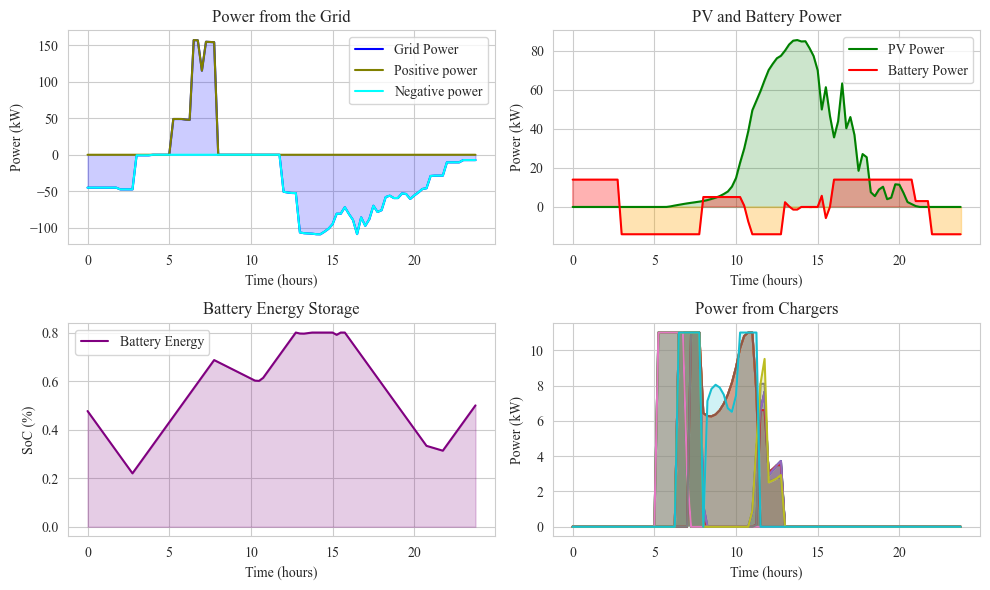

In [67]:
SCALE_FACTOR = 5


import cvxpy as cp
import numpy as np
import matplotlib.pyplot as plt

# Parameters
num_time_steps = 24*4  # 24 hours * 4 (15-minute resolution)
num_chargers = 4*SCALE_FACTOR

p_pv = expanded_pv[:num_time_steps+1]*SCALE_FACTOR / 1000  # PV power generation over time (size: num_time_steps)
charger_availability = np.hstack([charger_availability_data]*SCALE_FACTOR)  # Charger availability (size: num_chargers x num_time_steps)
ev_demand = np.hstack([np.array([20, 15, 25, 45])]*SCALE_FACTOR)  # Demand for each EV (size: num_chargers)
price = expanded_price[:num_time_steps+1]

time_resolution = 0.25  # 15 minutes

# Storage constraints
storage_capacity = 30*SCALE_FACTOR  # Example capacity
capacity_high_limit = 0.8
capacity_low_limit = 0.2

charge_discharge_limit = 14  # Example charge/discharge limit
p_charger_limit = 11

# Decision Variables
p_chargers = cp.Variable((num_time_steps+1, num_chargers), nonneg=True)
p_grid = cp.Variable(num_time_steps+1)
p_grid_positive = cp.Variable(num_time_steps+1, nonneg=True)
p_grid_negative = cp.Variable(num_time_steps+1, nonneg=True)
p_storage = cp.Variable(num_time_steps+1)
storage_energy = cp.Variable(num_time_steps+1, nonneg=True)
slack = cp.Variable(num_time_steps+1)  # Slack variable for power balance constraints

# Binary variables for big-M method
binary_pos = cp.Variable(num_time_steps+1, boolean=True)

# Big-M constant
M = 1e5

# Constraints
constraints = []

# Charger availability constraints
constraints.append(p_chargers <= charger_availability * p_charger_limit)

# Power balance constraints
constraints.append(p_pv + p_grid + p_storage + slack == cp.sum(p_chargers, axis=1))

constraints.append(storage_energy <= storage_capacity * capacity_high_limit)
constraints.append(storage_energy >= storage_capacity * capacity_low_limit)
constraints.append(p_storage <= charge_discharge_limit)
constraints.append(p_storage >= -charge_discharge_limit)
constraints.append(storage_energy[0] == storage_capacity / 2)  # Initial storage level
constraints.append(storage_energy[-1] == storage_capacity / 2)

constraints.append(storage_energy[1:] == storage_energy[:-1] - p_storage[1:] * time_resolution)

# Initial conditions
# constraints.append(self.p_grid[0] == self.p_grid_initial)
constraints.append(p_grid_positive[0] == 0)
constraints.append(p_grid_negative[0] == 0)

# EV demand constraints
constraints.append(cp.sum(p_chargers * time_resolution, axis=0) >= ev_demand)

# Auxiliary variables constraints
constraints.append(p_grid == p_grid_positive - p_grid_negative)

# Ensure p_grid_positive and p_grid_negative cannot be positive at the same time
constraints.append(binary_pos <= 1)
constraints.append(p_grid_positive <= binary_pos * M)
constraints.append(p_grid_negative <= (1-binary_pos) * M)

# Smoothing constraint to avoid abrupt changes
smoothing_penalty = cp.tv(p_grid_positive) + cp.tv(p_grid_negative) + cp.tv(p_storage) + 2*cp.tv(p_chargers) 

# Objective: Minimize total grid power usage, slack, and smoothing
objective = cp.Minimize(
    cp.sum(p_grid ** 2) +
    cp.sum(cp.multiply(price, p_grid_positive)) * 1000 -
    cp.sum(cp.multiply(price/2, p_grid_negative)) * 1000 +
    cp.sum(slack ** 2) * 1e3 +
    smoothing_penalty
)

# Problem definition and solving
problem = cp.Problem(objective, constraints)
problem.solve(solver=cp.SCIP, verbose=True)

# Output the results
print("Problem status:", problem.status)
if problem.status not in ["infeasible", "unbounded"]:
    print("Optimal objective value:", objective.value)
else:
    print("The problem is infeasible or unbounded.")

plt.figure(figsize=(10, 6))
time_steps = np.arange(len(p_grid.value[1:])) / 4  # Scale the time steps to hours

# Plot grid power
plt.subplot(2, 2, 1)
plt.plot(time_steps, p_grid.value[1:], label='Grid Power', color='blue')
plt.fill_between(time_steps, 0, p_grid.value[1:], color='blue', alpha=0.2)
plt.plot(time_steps, p_grid_positive.value[1:], label='Positive power', color='olive')
plt.plot(time_steps, -p_grid_negative.value[1:], label='Negative power', color='cyan')
plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('Power from the Grid')
plt.legend()

# Plot PV power and battery power
plt.subplot(2, 2, 2)
plt.plot(time_steps, p_pv[1:], label='PV Power', color='green')
plt.fill_between(time_steps, 0, p_pv[1:], color='green', alpha=0.2)
plt.plot(time_steps, p_storage.value[1:], label='Battery Power', color='red')
plt.fill_between(time_steps, 0, p_storage.value[1:], where=np.array(p_storage.value[1:]) >= 0, color='red', alpha=0.3, interpolate=True)
plt.fill_between(time_steps, 0, p_storage.value[1:], where=np.array(p_storage.value[1:]) < 0, color='orange', alpha=0.3, interpolate=True)
plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('PV and Battery Power')
plt.legend()

# Plot battery energy
plt.subplot(2, 2, 3)
plt.plot(time_steps, np.array(storage_energy.value[1:]) / storage_capacity, label='Battery Energy', color='purple')
plt.fill_between(time_steps, 0, np.array(storage_energy.value[1:]) / storage_capacity, color='purple', alpha=0.2)
plt.xlabel('Time (hours)')
plt.ylabel('SoC (%)')
plt.title('Battery Energy Storage')
plt.legend()

# Plot charger power
plt.subplot(2, 2, 4)
for i in range(4*SCALE_FACTOR):
    plt.plot(time_steps, p_chargers.value[1:, i], label=f'Charger {i + 1} Power')
    plt.fill_between(time_steps, 0, p_chargers.value[1:, i], alpha=0.2)

plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('Power from Chargers')
# plt.legend()

plt.tight_layout()
plt.show()


# MPC - Storage efficiency, PV fluctuations, ...

In [68]:
expanded_pv = np.hstack([np.zeros(1,), all_pv_profiles[100, :, 0]])
expanded_pv_forecast = np.hstack([np.zeros(1,), all_pv_profiles[100, :, 1]])
expanded_emmision = np.hstack([np.zeros(1,), co2_repeated.to_numpy()])

(97,) (4,) (97, 4) 75.0
(89,) (4,) (89, 4) 72.77186945906301
(81,) (4,) (81, 4) 71.0664485350252
(73,) (4,) (73, 4) 70.81102428244608
(65,) (4,) (65, 4) 66.74059319611551
(57,) (4,) (57, 4) 61.94139969956132
(49,) (4,) (49, 4) 56.65061025731166
(41,) (4,) (41, 4) 50.00239258417915
(33,) (4,) (33, 4) 49.76269751579744
(25,) (4,) (25, 4) 47.840323517777755
(17,) (4,) (17, 4) 41.861158671441835
(9,) (4,) (9, 4) 36.10170785555374


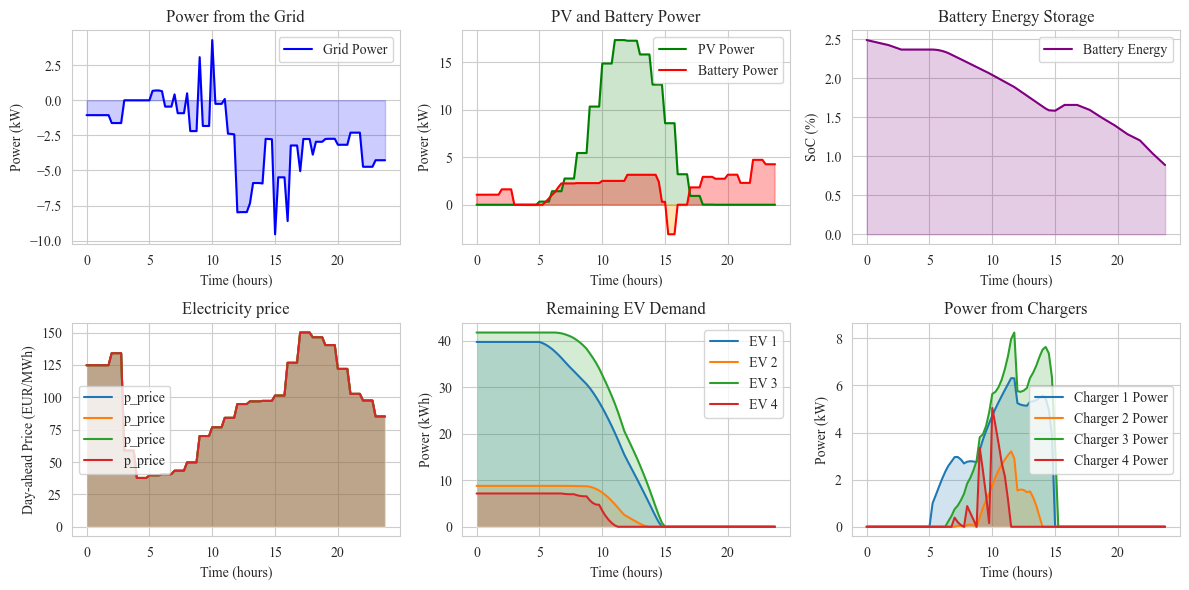

In [69]:
import cvxpy as cp
import numpy as np

class MPC:
    def __init__(self, num_chargers=4, time_resolution=0.25, storage_capacity=30,
                 capacity_high_limit=0.8, capacity_low_limit=0.2, p_storage_limit=14, p_charger_limit=11):
        self.num_chargers = num_chargers
        self.time_resolution = time_resolution
        self.storage_capacity = storage_capacity
        self.capacity_high_limit = capacity_high_limit
        self.capacity_low_limit = capacity_low_limit
        self.p_storage_limit = p_storage_limit
        self.p_charger_limit = p_charger_limit

        # 2 hours * resolution
        self.time_shift = 2 * int(1 / self.time_resolution)  
        # Big-M constant
        self.M = 1e5

    def step(self, p_pv, results, charger_availability, p_price, e_factor):
        self.num_time_steps = len(p_pv)  # 24 hours * resolution

        # Initialize parameters
        self.p_grid_initial = cp.Parameter(1, value=results['p_grid'][-1:])
        self.p_grid_positive_initial = cp.Parameter(1, nonneg=True, value=np.clip(results['p_grid_positive'][-1:], 0, np.inf))
        self.p_grid_negative_initial = cp.Parameter(1, nonneg=True, value=np.clip(results['p_grid_negative'][-1:], 0, np.inf))

        self.p_storage_initial = cp.Parameter(1, value=np.clip(results['p_storage'][-1:], -self.p_storage_limit, self.p_storage_limit))
        self.p_chargers_initial = cp.Parameter(self.num_chargers, nonneg=True, value=np.clip(results['p_chargers'][-1,:], 0, self.p_charger_limit))
        self.storage_energy_initial = cp.Parameter(1, nonneg=True, value=np.clip(results['storage_energy'][-1:], 
                                                                                 self.storage_capacity*self.capacity_low_limit, 
                                                                                 self.storage_capacity*self.capacity_high_limit))

        self.ev_demand = cp.Parameter(self.num_chargers, nonneg=True, value=np.clip(results['remaining_demand'][-1,:], 0, np.inf))
        self.charger_availability = cp.Parameter((self.num_time_steps, self.num_chargers), boolean=True, value=charger_availability)
        self.p_price = cp.Parameter(self.num_time_steps, value=p_price)
        self.e_factor = cp.Parameter(self.num_time_steps, value=e_factor)

        # Initialize decision variables
        self.p_chargers = cp.Variable((self.num_time_steps, self.num_chargers), nonneg=True)
        self.p_grid = cp.Variable(self.num_time_steps)
        self.p_grid_positive = cp.Variable(self.num_time_steps, nonneg=True)
        self.p_grid_negative = cp.Variable(self.num_time_steps, nonneg=True)
        self.p_storage = cp.Variable(self.num_time_steps)
        self.storage_energy = cp.Variable(self.num_time_steps, nonneg=True)

        # Binary variables for big-M method
        self.binary_pos = cp.Variable(self.num_time_steps, boolean=True)

        # Constraints
        constraints = []

        # Charger availability constraints
        constraints.append(self.p_chargers <= charger_availability*self.p_charger_limit)

        # Power balance constraints
        constraints.append(p_pv[1:] + self.p_grid[1:] + self.p_storage[1:] == cp.sum(self.p_chargers, axis=1)[1:])

        # Storage constraints
        constraints.append(self.storage_energy <= self.storage_capacity * self.capacity_high_limit)
        constraints.append(self.storage_energy >= self.storage_capacity * self.capacity_low_limit)
        constraints.append(self.p_storage <= self.p_storage_limit)
        constraints.append(self.p_storage >= -self.p_storage_limit)

        # Initial conditions
        # constraints.append(self.p_grid[0] == self.p_grid_initial)
        constraints.append(self.p_grid_positive[0] == self.p_grid_positive_initial)
        constraints.append(self.p_grid_negative[0] == self.p_grid_negative_initial)

        constraints.append(self.p_storage[0] == self.p_storage_initial)
        constraints.append(self.p_chargers[0] == self.p_chargers_initial)
        constraints.append(self.storage_energy[0] == self.storage_energy_initial)
        constraints.append(self.storage_energy[-1] == self.storage_capacity/2)

        # Storage dynamics
        constraints.append(self.storage_energy[1:] == self.storage_energy[:-1] - self.p_storage[1:]*self.time_resolution)

        # EV demand constraints
        constraints.append(cp.sum(self.p_chargers[1:]*self.time_resolution, axis=0) == self.ev_demand)

        # Auxiliary variables constraints
        constraints.append(self.p_grid == self.p_grid_positive - self.p_grid_negative)

        # Ensure p_grid_positive and p_grid_negative cannot be positive at the same time
        constraints.append(self.binary_pos <= 1)
        constraints.append(self.p_grid_positive <= self.binary_pos * self.M)
        constraints.append(self.p_grid_negative <= (1-self.binary_pos) * self.M)

        # Smoothing constraint to avoid abrupt changes: total variations
        smoothing_penalty = cp.tv(self.p_grid_positive) + cp.tv(self.p_grid_negative) + cp.tv(self.p_storage) + 2*cp.tv(self.p_chargers) 

        # Objective: Minimize total grid power usage
        objective = cp.Minimize(cp.sum(self.p_grid**2)*5
                                + cp.sum(cp.multiply(self.p_price,self.p_grid_positive))
                                - cp.sum(cp.multiply(self.p_price/2,self.p_grid_negative))
                                + cp.sum(cp.multiply(self.e_factor, self.p_grid))
                                + smoothing_penalty)

        # Problem definition and solving
        problem = cp.Problem(objective, constraints)
        problem.solve(solver=cp.SCIP)
        
        # Output the results
        if problem.status not in ["infeasible", "unbounded"]:
            return {
                "status": problem.status,
                "objective_value": objective.value,
                "p_grid": np.array(self.p_grid.value)[1:1+self.time_shift],
                "p_grid_positive": np.array(self.p_grid_positive.value)[1:1+self.time_shift],
                "p_grid_negative": np.array(self.p_grid_negative.value)[1:1+self.time_shift],
                "p_chargers": np.array(self.p_chargers.value)[1:1+self.time_shift,:],
                "p_storage": np.array(self.p_storage.value)[1:1+self.time_shift],
            }
        else:
            print("The problem is infeasible or unbounded.")

# Example usage:
# Parameters
num_time_steps = 24*4  # 24 hours * 4 (15-minute resolution)
num_chargers = 4

ev_demand_initial = ev_demand_initial_sample.reshape(1,4) # Example EV demand
storage_energy_initial = np.array([storage_capacity]) / 2

# Storage constraints
storage_capacity = 30  # Example capacity
capacity_high_imit = 0.8
capacity_low_imit = 0.2

mpc = MPC()
current_time = 0
time_shift = 2 * int(1 / mpc.time_resolution)  # 2 hours * resolution

results = {
    'p_grid':           np.zeros((1,)),
    'p_grid_ideal':     np.zeros((1,)),
    'p_grid_positive':  np.zeros((1,)),
    'p_grid_negative':  np.zeros((1,)),
    'p_storage':        np.zeros((1,)),
    'storage_energy':   storage_energy_initial,
    'p_chargers':       np.zeros((1, num_chargers)),
    'remaining_demand': ev_demand_initial,
}

for t in range(1, num_time_steps, time_shift):
    p_pv = expanded_pv_forecast[t-1:]/ 1000  # PV power generation over time
    p_pv_real = expanded_pv[t-1:]/ 1000 
    charger_availability = charger_availability_data[t-1:, :mpc.num_chargers]  # Charger availability
    p_price = expanded_price[t-1:]
    e_factor = expanded_emmision[t-1:]  # Emission factor for the time period

    print(p_pv.shape, results['remaining_demand'][-1,:].shape, charger_availability.shape, results['storage_energy'][-1])
    command = mpc.step(p_pv, results, charger_availability, p_price, e_factor)

    # apply dynamics of storage and demands
    storage_energy_samples = results['storage_energy'][-1] - (1/0.95)*np.cumsum(np.maximum(0, command['p_storage']))*mpc.time_resolution -\
                                                             (0.95) * np.cumsum(np.minimum(0, command['p_storage']))*time_resolution
    ev_demand_samples = results['remaining_demand'][-1].reshape(1,4) - np.cumsum(command['p_chargers'], axis=0)*mpc.time_resolution
    
    p_grid_samples = np.sum(command['p_chargers'], axis=1) - command['p_storage'] - p_pv_real[:time_shift]
    p_grid_positive_samples = np.maximum(p_grid_samples, 0)
    p_grid_negative_samples = np.minimum(p_grid_samples, 0)

    # Store results
    results['p_grid_ideal'] = np.hstack([results['p_grid_ideal'], command['p_grid']])
    results['p_grid'] = np.hstack([results['p_grid'], p_grid_samples])
    results['p_grid_positive'] = np.hstack([results['p_grid_positive'], p_grid_positive_samples])
    results['p_grid_negative'] = np.hstack([results['p_grid_negative'], p_grid_negative_samples])


    results['p_storage'] = np.hstack([results['p_storage'], command['p_storage']])
    results['p_chargers'] = np.vstack([results['p_chargers'], command['p_chargers']])
    results['storage_energy'] = np.hstack([results['storage_energy'], storage_energy_samples])
    results['remaining_demand'] = np.vstack([results['remaining_demand'], ev_demand_samples])
    
    # if t == 4*time_shift+1:
    #     break

for key in results.keys():
    if key not in ['storage_energy', 'remaining_demand']:
        results[key] = results[key][1:]
    else:
        results[key] = results[key][1:]
        
plt.figure(figsize=(12, 6))
time_steps = np.arange(len(results['p_grid'])) / 4  # Scale the time steps to hours

# Plot grid power
plt.subplot(2, 3, 1)
plt.plot(time_steps, results['p_grid'], label='Grid Power', color='blue')
plt.fill_between(time_steps, 0, results['p_grid'], color='blue', alpha=0.2)
plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('Power from the Grid')
plt.legend()

# Plot PV power and battery power
plt.subplot(2, 3, 2)
plt.plot(time_steps, expanded_pv[1:1+len(time_steps)]/1000, label='PV Power', color='green')
plt.fill_between(time_steps, 0, expanded_pv[1:1+len(time_steps)]/1000, color='green', alpha=0.2)
plt.plot(time_steps, results['p_storage'], label='Battery Power', color='red')
plt.fill_between(time_steps, 0, results['p_storage'], where=np.array(results['p_storage']) >= 0, color='red', alpha=0.3, interpolate=True)
plt.fill_between(time_steps, 0, results['p_storage'], where=np.array(results['p_storage']) < 0, color='orange', alpha=0.3, interpolate=True)
plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('PV and Battery Power')
plt.legend()

# Plot battery energy
plt.subplot(2, 3, 3)
plt.plot(time_steps, np.array(results['storage_energy'])/storage_capacity, label='Battery Energy', color='purple')
plt.fill_between(time_steps, 0, np.array(results['storage_energy'])/storage_capacity, color='purple', alpha=0.2)
plt.xlabel('Time (hours)')
plt.ylabel('SoC (%)')
plt.title('Battery Energy Storage')
plt.legend()

# Plot electricity price
plt.subplot(2, 3, 4)
for i in range(4):
    plt.plot(time_steps, expanded_price[1:1+len(time_steps)], label=f'p_price')
    plt.fill_between(time_steps, 0, expanded_price[1:1+len(time_steps)], alpha=0.2)
plt.xlabel('Time (hours)')
plt.ylabel('Day-ahead Price (EUR/MWh)')
plt.title('Electricity price')
plt.legend()

# Plot EV demand
plt.subplot(2, 3, 5)
for i in range(4):
    plt.plot(time_steps, results['remaining_demand'][:,i], label=f'EV {i+1}')
    plt.fill_between(time_steps, 0, results['remaining_demand'][:,i], alpha=0.2)
plt.xlabel('Time (hours)')
plt.ylabel('Power (kWh)')
plt.title('Remaining EV Demand')
plt.legend()

# Plot charger power
plt.subplot(2, 3, 6)
for i in range(4):
    plt.plot(time_steps, results['p_chargers'][:,i], label=f'Charger {i+1} Power')
    plt.fill_between(time_steps, 0, results['p_chargers'][:,i], alpha=0.2)
plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('Power from Chargers')
plt.legend()

plt.tight_layout()
plt.show()

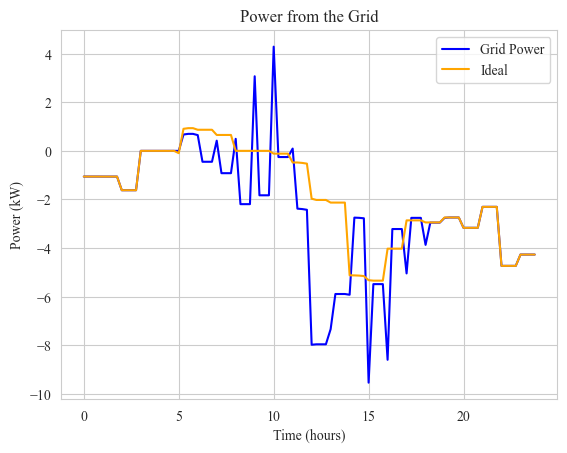

In [70]:
plt.plot(time_steps, results['p_grid'], label='Grid Power', color='blue')
plt.plot(time_steps, results['p_grid_ideal'], label='Ideal', color='orange')

# plt.fill_between(time_steps, 0, results['p_grid'], color='blue', alpha=0.2)
plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('Power from the Grid')
plt.legend()

# Using battery as a buffer

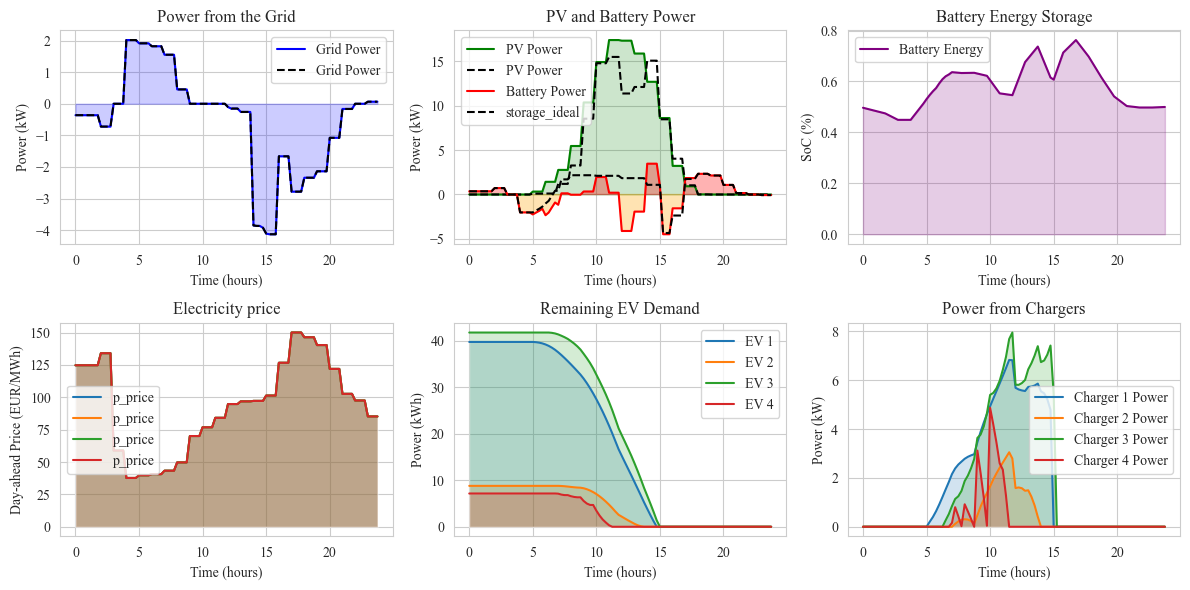

In [71]:
import cvxpy as cp
import numpy as np

class MPC:
    def __init__(self, num_chargers=4, time_resolution=0.25, storage_capacity=30,
                 capacity_high_limit=0.8, capacity_low_limit=0.2, p_storage_limit=14, p_charger_limit=11):
        self.num_chargers = num_chargers
        self.time_resolution = time_resolution
        self.storage_capacity = storage_capacity
        self.capacity_high_limit = capacity_high_limit
        self.capacity_low_limit = capacity_low_limit
        self.p_storage_limit = p_storage_limit
        self.p_charger_limit = p_charger_limit

        # 2 hours * resolution
        self.time_shift = 2 * int(1 / self.time_resolution)  
        # Big-M constant
        self.M = 1e5

    def step(self, p_pv, results, charger_availability, p_price, e_factor):
        self.num_time_steps = len(p_pv)  # 24 hours * resolution

        # Initialize parameters
        self.p_grid_initial = cp.Parameter(1, value=results['p_grid'][-1:])
        self.p_grid_positive_initial = cp.Parameter(1, nonneg=True, value=np.clip(results['p_grid_positive'][-1:], 0, np.inf))
        self.p_grid_negative_initial = cp.Parameter(1, nonneg=True, value=np.clip(results['p_grid_negative'][-1:], 0, np.inf))

        self.p_storage_initial = cp.Parameter(1, value=np.clip(results['p_storage'][-1:], -self.p_storage_limit, self.p_storage_limit))
        self.p_chargers_initial = cp.Parameter(self.num_chargers, nonneg=True, value=np.clip(results['p_chargers'][-1,:], 0, self.p_charger_limit))
        self.storage_energy_initial = cp.Parameter(1, nonneg=True, value=np.clip(results['storage_energy'][-1:], 
                                                                                 self.storage_capacity*self.capacity_low_limit, 
                                                                                 self.storage_capacity*self.capacity_high_limit))

        self.ev_demand = cp.Parameter(self.num_chargers, nonneg=True, value=np.clip(results['remaining_demand'][-1,:], 0, np.inf))
        self.charger_availability = cp.Parameter((self.num_time_steps, self.num_chargers), boolean=True, value=charger_availability)
        self.p_price = cp.Parameter(self.num_time_steps, value=p_price)
        self.e_factor = cp.Parameter(self.num_time_steps, value=e_factor)

        # Initialize decision variables
        self.p_chargers = cp.Variable((self.num_time_steps, self.num_chargers), nonneg=True)
        self.p_grid = cp.Variable(self.num_time_steps)
        self.p_grid_positive = cp.Variable(self.num_time_steps, nonneg=True)
        self.p_grid_negative = cp.Variable(self.num_time_steps, nonneg=True)
        self.p_storage = cp.Variable(self.num_time_steps)
        self.storage_energy = cp.Variable(self.num_time_steps, nonneg=True)

        # Binary variables for big-M method
        self.binary_pos = cp.Variable(self.num_time_steps, boolean=True)

        # Constraints
        constraints = []

        # Charger availability constraints
        constraints.append(self.p_chargers <= charger_availability*self.p_charger_limit)

        # Power balance constraints
        constraints.append(p_pv[1:] + self.p_grid[1:] + self.p_storage[1:] == cp.sum(self.p_chargers, axis=1)[1:])

        # Storage constraints
        constraints.append(self.storage_energy[1:] <= self.storage_capacity * self.capacity_high_limit)
        constraints.append(self.storage_energy[1:] >= self.storage_capacity * self.capacity_low_limit)
        constraints.append(self.p_storage <= self.p_storage_limit)
        constraints.append(self.p_storage >= -self.p_storage_limit)

        # Initial conditions
        # constraints.append(self.p_grid[0] == self.p_grid_initial)
        constraints.append(self.p_grid_positive[0] == self.p_grid_positive_initial)
        constraints.append(self.p_grid_negative[0] == self.p_grid_negative_initial)

        constraints.append(self.p_storage[0] == self.p_storage_initial)
        constraints.append(self.p_chargers[0] == self.p_chargers_initial)
        constraints.append(self.storage_energy[0] == self.storage_energy_initial)
        constraints.append(self.storage_energy[-1] == self.storage_capacity/2)

        # Storage dynamics
        constraints.append(self.storage_energy[1:] == self.storage_energy[:-1] - self.p_storage[1:]*self.time_resolution)

        # EV demand constraints
        constraints.append(cp.sum(self.p_chargers[1:]*self.time_resolution, axis=0) == self.ev_demand)

        # Auxiliary variables constraints
        constraints.append(self.p_grid == self.p_grid_positive - self.p_grid_negative)

        # Ensure p_grid_positive and p_grid_negative cannot be positive at the same time
        constraints.append(self.binary_pos <= 1)
        constraints.append(self.p_grid_positive <= self.binary_pos * self.M)
        constraints.append(self.p_grid_negative <= (1-self.binary_pos) * self.M)

        # Smoothing constraint to avoid abrupt changes: total variations
        smoothing_penalty = cp.tv(self.p_grid_positive) + cp.tv(self.p_grid_negative) + cp.tv(self.p_storage) + 2*cp.tv(self.p_chargers) 

        # Objective: Minimize total grid power usage
        objective = cp.Minimize(cp.sum(self.p_grid**2)*5
                                + cp.sum(cp.multiply(self.p_price,self.p_grid_positive))
                                - cp.sum(cp.multiply(self.p_price/2,self.p_grid_negative))
                                + cp.sum(cp.multiply(self.e_factor, self.p_grid))
                                + smoothing_penalty)

        # Problem definition and solving
        problem = cp.Problem(objective, constraints)
        problem.solve(solver=cp.SCIP)
        
        # Output the results
        if problem.status not in ["infeasible", "unbounded"]:
            return {
                "status": problem.status,
                "objective_value": objective.value,
                "p_grid": np.array(self.p_grid.value)[1:1+self.time_shift],
                "p_grid_positive": np.array(self.p_grid_positive.value)[1:1+self.time_shift],
                "p_grid_negative": np.array(self.p_grid_negative.value)[1:1+self.time_shift],
                "p_chargers": np.array(self.p_chargers.value)[1:1+self.time_shift,:],
                "p_storage": np.array(self.p_storage.value)[1:1+self.time_shift],
            }
        else:
            print("The problem is infeasible or unbounded.")

# Example usage:
# Parameters
num_time_steps = 24*4  # 24 hours * 4 (15-minute resolution)
num_chargers = 4

ev_demand_initial = ev_demand_initial_sample.reshape(1,4) # Example EV demand
storage_energy_initial = np.array([storage_capacity]) / 2

# Storage constraints
storage_capacity = 30  # Example capacity
capacity_high_imit = 0.85
capacity_low_imit = 0.2

mpc = MPC()
current_time = 0
time_shift = 2 * int(1 / mpc.time_resolution)  # 2 hours * resolution

results = {
    'p_grid':           np.zeros((1,)),
    'p_grid_ideal':     np.zeros((1,)),
    'p_grid_positive':  np.zeros((1,)),
    'p_grid_negative':  np.zeros((1,)),
    'p_storage':        np.zeros((1,)),
    'p_storage_ideal':  np.zeros((1,)),
    'storage_energy':   storage_energy_initial,
    'p_chargers':       np.zeros((1, num_chargers)),
    'remaining_demand': ev_demand_initial,
}

for t in range(1, num_time_steps, time_shift):
    p_pv = expanded_pv_forecast[t-1:]/ 1000  # PV power generation over time
    p_pv_real = expanded_pv[t-1:]/ 1000 
    charger_availability = charger_availability_data[t-1:, :mpc.num_chargers]  # Charger availability
    p_price = expanded_price[t-1:]
    e_factor = expanded_emmision[t-1:]  # Emission factor for the time period

    # print(p_pv.shape, results['remaining_demand'][-1,:].shape, charger_availability.shape, results['storage_energy'][-1])
    command = mpc.step(p_pv, results, charger_availability, p_price, e_factor)

    # Adjust for actual PV power using the battery
    pv_error = p_pv_real[1:time_shift+1] - p_pv[1:time_shift+1]  # Compute forecast error

    # Initialize adjusted battery power
    adjusted_p_storage = command['p_storage'].copy()
    current_storage_energy = results['storage_energy'][-1].copy()  # Current SoC
    # break
    # print(t)
    # if t >= 57:
    #     break
    # Adjust battery power to absorb PV error
    for i in range(time_shift):
        adjusted_p_storage[i] = adjusted_p_storage[i] - pv_error[i]
        adjusted_p_storage[i] = np.clip(adjusted_p_storage[i], -mpc.p_storage_limit, mpc.p_storage_limit)  # Ensure discharging does not exceed limit
        adjusted_p_storage[i] = -np.clip(-adjusted_p_storage[i], 
                                        -np.negative(mpc.storage_capacity*mpc.capacity_low_limit - current_storage_energy) / mpc.time_resolution,
                                         np.positive(mpc.storage_capacity*mpc.capacity_high_limit - current_storage_energy) / mpc.time_resolution)
        
        # Update SoC for the next iteration
        current_storage_energy = current_storage_energy - \
                                 (1/0.95) * np.maximum(0, adjusted_p_storage[i]) * mpc.time_resolution - \
                                 (0.95) * np.minimum(0, adjusted_p_storage[i]) * mpc.time_resolution

    # Adjust grid power based on adjusted battery power
    p_grid_samples = np.sum(command['p_chargers'], axis=1) - adjusted_p_storage - p_pv_real[1:time_shift+1]
    p_grid_positive_samples = np.maximum(p_grid_samples, 0)
    p_grid_negative_samples = np.minimum(p_grid_samples, 0)
    # if t == 57:
    #     print(f"t: {t}, charger: {np.sum(command['p_chargers'], axis=1)},\n adjusted_p_storage: {adjusted_p_storage},\n pv real: {p_pv_real[:time_shift]},\n \
    #           pv forecast: {p_pv[:time_shift]} \n adjusted grid: {p_grid_samples}, p_grid :{command['p_grid']}")

    # print(f"time {t}-{t+time_shift-1},\n p_grid: {command['p_grid']},\n adjusted p_grid: {p_grid_samples},\n p_storage: {command['p_storage']},\n adjusted p_storage: {adjusted_p_storage},\n p_error: {pv_error}")
    # Update storage energy based on adjusted battery power
    storage_energy_samples = results['storage_energy'][-1] - \
                            (1/0.95) * np.cumsum(np.maximum(0, adjusted_p_storage)) * mpc.time_resolution - \
                            (0.95) * np.cumsum(np.minimum(0, adjusted_p_storage)) * mpc.time_resolution

    # EV demand update (unchanged)
    ev_demand_samples = results['remaining_demand'][-1].reshape(1, 4) - \
                        np.cumsum(command['p_chargers'], axis=0) * mpc.time_resolution


    # Store results
    results['p_grid_ideal'] = np.hstack([results['p_grid_ideal'], command['p_grid']])
    results['p_grid'] = np.hstack([results['p_grid'], p_grid_samples])
    results['p_grid_positive'] = np.hstack([results['p_grid_positive'], p_grid_positive_samples])
    results['p_grid_negative'] = np.hstack([results['p_grid_negative'], p_grid_negative_samples])


    results['p_chargers'] = np.vstack([results['p_chargers'], command['p_chargers']])
    results['p_storage'] = np.hstack([results['p_storage'], adjusted_p_storage])
    results['p_storage_ideal'] = np.hstack([results['p_storage_ideal'], command['p_storage']])
    results['storage_energy'] = np.hstack([results['storage_energy'], storage_energy_samples])
    results['remaining_demand'] = np.vstack([results['remaining_demand'], ev_demand_samples])
    # if t == 4*time_shift+1:
    #     break

for key in results.keys():
    if key not in ['storage_energy', 'remaining_demand']:
        results[key] = results[key][1:]
    else:
        results[key] = results[key][1:]
        
plt.figure(figsize=(12, 6))
time_steps = np.arange(len(results['p_grid'])) / 4  # Scale the time steps to hours

# Plot grid power
plt.subplot(2, 3, 1)
plt.plot(time_steps, results['p_grid'], label='Grid Power', color='blue')
plt.fill_between(time_steps, 0, results['p_grid'], color='blue', alpha=0.2)
plt.plot(time_steps, results['p_grid_ideal'], label='Grid Power', color='black', linestyle='--')

plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('Power from the Grid')
plt.legend()

# Plot PV power and battery power
plt.subplot(2, 3, 2)
plt.plot(time_steps, expanded_pv[1:1+len(time_steps)]/1000, label='PV Power', color='green')
plt.fill_between(time_steps, 0, expanded_pv[1:1+len(time_steps)]/1000, color='green', alpha=0.2)
plt.plot(time_steps, expanded_pv_forecast[1:1+len(time_steps)]/1000, label='PV Power', color='black', linestyle='--')

plt.plot(time_steps, results['p_storage'], label='Battery Power', color='red')
plt.fill_between(time_steps, 0, results['p_storage'], where=np.array(results['p_storage']) >= 0, color='red', alpha=0.3, interpolate=True)
plt.fill_between(time_steps, 0, results['p_storage'], where=np.array(results['p_storage']) < 0, color='orange', alpha=0.3, interpolate=True)
plt.plot(time_steps, results['p_storage_ideal'], label='storage_ideal', color='black', linestyle='--')

plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('PV and Battery Power')
plt.legend()

# Plot battery energy
plt.subplot(2, 3, 3)
plt.plot(time_steps, np.array(results['storage_energy'])/storage_capacity, label='Battery Energy', color='purple')
plt.fill_between(time_steps, 0, np.array(results['storage_energy'])/storage_capacity, color='purple', alpha=0.2)
plt.xlabel('Time (hours)')
plt.ylabel('SoC (%)')
plt.title('Battery Energy Storage')
plt.legend()

# Plot electricity price
plt.subplot(2, 3, 4)
for i in range(4):
    plt.plot(time_steps, expanded_price[1:1+len(time_steps)], label=f'p_price')
    plt.fill_between(time_steps, 0, expanded_price[1:1+len(time_steps)], alpha=0.2)
plt.xlabel('Time (hours)')
plt.ylabel('Day-ahead Price (EUR/MWh)')
plt.title('Electricity price')
plt.legend()

# Plot EV demand
plt.subplot(2, 3, 5)
for i in range(4):
    plt.plot(time_steps, results['remaining_demand'][:,i], label=f'EV {i+1}')
    plt.fill_between(time_steps, 0, results['remaining_demand'][:,i], alpha=0.2)
plt.xlabel('Time (hours)')
plt.ylabel('Power (kWh)')
plt.title('Remaining EV Demand')
plt.legend()

# Plot charger power
plt.subplot(2, 3, 6)
for i in range(4):
    plt.plot(time_steps, results['p_chargers'][:,i], label=f'Charger {i+1} Power')
    plt.fill_between(time_steps, 0, results['p_chargers'][:,i], alpha=0.2)
plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('Power from Chargers')
plt.legend()

plt.tight_layout()
plt.show()

# EV uncertainty

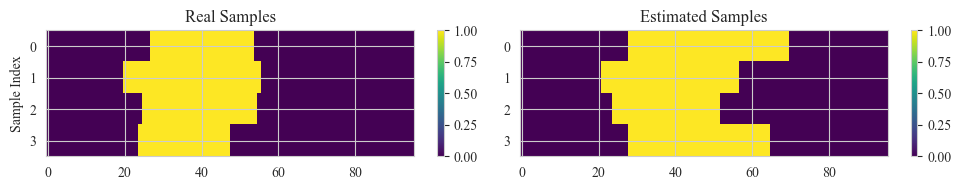

In [223]:
import numpy as np
import matplotlib.pyplot as plt

def get_filtered_samples(mdn1, mdn2, mdn3, n_samples=5000, n_return=4):
    samples = sample_autoregressive(mdn1, mdn2, mdn3, n_samples=n_samples)
    arrival_samples = samples[:, 0]
    duration_samples = samples[:, 1]
    energy_samples = samples[:, 2]

    # Filter the samples
    mask = (arrival_samples >= 0) & (duration_samples >= 5) & (energy_samples >= 0)
    filtered_arrivals = arrival_samples[mask][:n_return]
    filtered_durations = duration_samples[mask][:n_return]
    filtered_energies = energy_samples[mask][:n_return]

    return filtered_arrivals, filtered_durations, filtered_energies/4

def compute_availability(arrival_times, durations, n_slots=96):
    n_samples = len(arrival_times)
    # Convert hours to 15-minute slots (vectorized)
    arrival_slots = np.clip((arrival_times * 4).astype(int), 0, n_slots - 1)
    duration_slots = (durations * 4).astype(int)
    departure_slots = arrival_slots + duration_slots
    # Create time slot indices for broadcasting
    slot_indices = np.arange(n_slots)  # Shape: (n_slots,)
    start_mask = slot_indices >= arrival_slots[:, None]  # (n_samples, n_slots)
    # Handle normal case (departure within day) and wrap-around case
    normal_case = departure_slots <= n_slots
    end_mask_normal = slot_indices < departure_slots[:, None]  # (n_samples, n_slots)
    end_mask_wraparound = slot_indices < (departure_slots % n_slots)[:, None]  # (n_samples, n_slots)
    # Create availability matrix
    availability_matrix = np.zeros((n_samples, n_slots), dtype=int)
    # Normal case: within same day
    normal_mask = normal_case[:, None]  # (n_samples, 1)
    availability_matrix = np.where(
        normal_mask,
        start_mask & end_mask_normal,
        start_mask | end_mask_wraparound  # Wrap-around case
    )
    return availability_matrix.astype(int)

# Sample once for real
real_arrivals, real_durations, real_energies = get_filtered_samples(mdn1, mdn2, mdn3)

# Sample once for estimate
est_arrivals, est_durations, est_energies = get_filtered_samples(mdn1, mdn2, mdn3)

real_availability_matrix = compute_availability(real_arrivals, real_durations)
est_availability_matrix = compute_availability(est_arrivals, est_durations)

# Plotting with imshow
fig, axs = plt.subplots(1, 2, figsize=(10, 2))

im0 = axs[0].imshow(real_availability_matrix, aspect='auto', cmap='viridis')
axs[0].set_title("Real Samples")
axs[0].set_yticks(range(4))
axs[0].set_ylabel("Sample Index")
plt.colorbar(im0, ax=axs[0])

im1 = axs[1].imshow(est_availability_matrix, aspect='auto', cmap='viridis')
axs[1].set_title("Estimated Samples")
axs[1].set_yticks(range(4))
plt.colorbar(im1, ax=axs[1])

plt.tight_layout()
plt.show()


In [224]:
def sample_duration_given_arrival(mdn2, arrival):
    """Sample duration given a specific arrival time."""
    # sample x2 ~ p(x2 | x1)
    arrival_tensor = torch.tensor(arrival).reshape(-1,1).float()  # shape: (1, 1)
    pi2, mu2, sigma2 = mdn2(arrival_tensor)
    duration_sample = mdn2.sample(pi2, mu2, sigma2)  # shape: (1, 1)
    return duration_sample.detach().numpy().flatten()

sample_duration_given_arrival(mdn2, [9])

array([4.074344], dtype=float32)

In [225]:
# Sample once for estimate
est_arrivals_temp, est_durations_temp, est_energies_temp = est_arrivals.copy(), est_durations.copy(), est_energies.copy()
est_availability_matrix_temp = est_availability_matrix.copy()


In [226]:
# reverse the process to get the original arrival times and durations
est_arrivals, est_durations, est_energies = est_arrivals_temp.copy(), est_durations_temp.copy(), est_energies_temp.copy()
est_availability_matrix = est_availability_matrix_temp.copy()

t: 1, real arrivals: [6.9657073 5.0123825 6.284466  6.1347904], est arrivals: [7.0693607 5.4973645 6.0978847 7.0782633]
t: 1, pv_error: [0.], ev_error: [0.]
t: 2, real arrivals: [6.9657073 5.0123825 6.284466  6.1347904], est arrivals: [7.0693607 5.4973645 6.0978847 7.0782633]
t: 2, pv_error: [0.], ev_error: [0.]
t: 3, real arrivals: [6.9657073 5.0123825 6.284466  6.1347904], est arrivals: [7.0693607 5.4973645 6.0978847 7.0782633]
t: 3, pv_error: [0.], ev_error: [0.]
t: 4, real arrivals: [6.9657073 5.0123825 6.284466  6.1347904], est arrivals: [7.0693607 5.4973645 6.0978847 7.0782633]
t: 4, pv_error: [0.], ev_error: [0.]
t: 5, real arrivals: [6.9657073 5.0123825 6.284466  6.1347904], est arrivals: [7.0693607 5.4973645 6.0978847 7.0782633]
t: 5, pv_error: [0.], ev_error: [0.]
t: 6, real arrivals: [6.9657073 5.0123825 6.284466  6.1347904], est arrivals: [7.0693607 5.4973645 6.0978847 7.0782633]
t: 6, pv_error: [0.], ev_error: [0.]
t: 7, real arrivals: [6.9657073 5.0123825 6.284466  6.1347

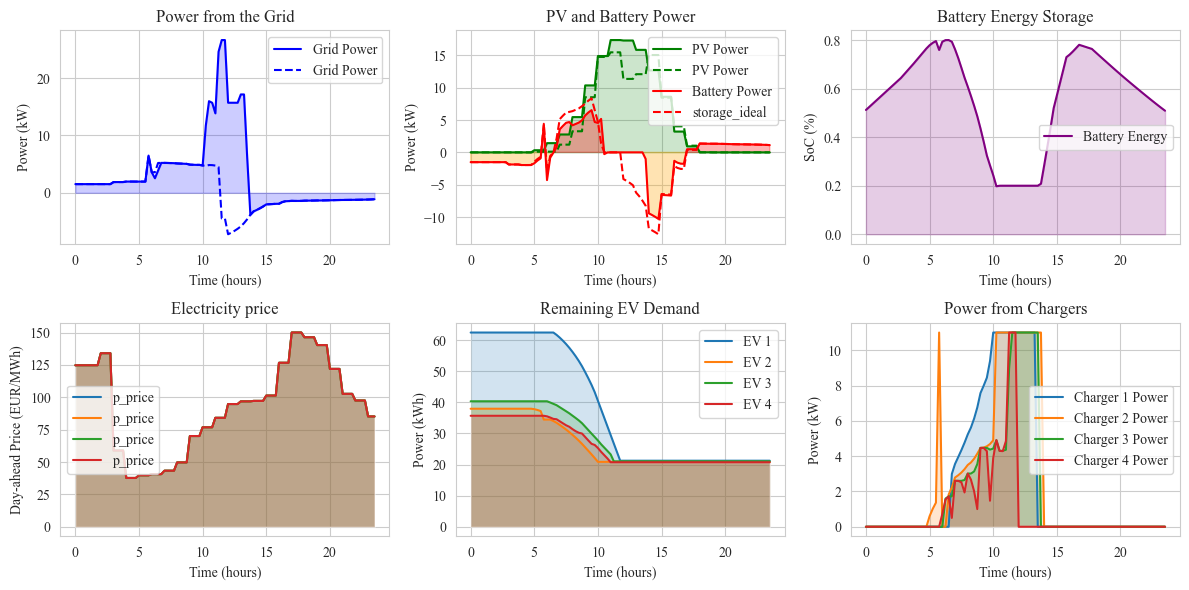

In [227]:
import cvxpy as cp
import numpy as np

class MPC:
    def __init__(self, num_chargers=4, time_resolution=0.25, storage_capacity=30,
                 capacity_high_limit=0.8, capacity_low_limit=0.2, p_storage_limit=14, p_charger_limit=11):
        self.num_chargers = num_chargers
        self.time_resolution = time_resolution
        self.storage_capacity = storage_capacity
        self.capacity_high_limit = capacity_high_limit
        self.capacity_low_limit = capacity_low_limit
        self.p_storage_limit = p_storage_limit
        self.p_charger_limit = p_charger_limit

        # 1 hours * resolution
        self.time_shift = int(0.25 / self.time_resolution)  
        # Big-M constant
        self.M = 1e5

    def step(self, p_pv, results, charger_availability, p_price, e_factor):
        self.num_time_steps = len(p_pv)  # 24 hours * resolution

        # Initialize parameters
        self.p_grid_initial = cp.Parameter(1, value=results['p_grid'][-1:])
        self.p_grid_positive_initial = cp.Parameter(1, nonneg=True, value=np.clip(results['p_grid_positive'][-1:], 0, np.inf))
        self.p_grid_negative_initial = cp.Parameter(1, nonneg=True, value=np.clip(results['p_grid_negative'][-1:], 0, np.inf))

        self.p_storage_initial = cp.Parameter(1, value=np.clip(results['p_storage'][-1:], -self.p_storage_limit, self.p_storage_limit))
        self.p_chargers_initial = cp.Parameter(self.num_chargers, nonneg=True, value=np.clip(results['p_chargers'][-1,:], 0, self.p_charger_limit))
        self.storage_energy_initial = cp.Parameter(1, nonneg=True, value=np.clip(results['storage_energy'][-1:], 
                                                                                 self.storage_capacity*self.capacity_low_limit, 
                                                                                 self.storage_capacity*self.capacity_high_limit))

        self.ev_demand = cp.Parameter(self.num_chargers, nonneg=True, value=np.clip(results['remaining_demand'][-1,:], 0, np.inf))
        self.charger_availability = cp.Parameter((self.num_time_steps, self.num_chargers), boolean=True, value=charger_availability)
        self.p_price = cp.Parameter(self.num_time_steps, value=p_price)
        self.e_factor = cp.Parameter(self.num_time_steps, value=e_factor)

        # Initialize decision variables
        self.p_chargers = cp.Variable((self.num_time_steps, self.num_chargers), nonneg=True)
        self.p_chargers_slack = cp.Variable(self.num_chargers, nonneg=False)
        self.p_grid = cp.Variable(self.num_time_steps)
        self.p_grid_positive = cp.Variable(self.num_time_steps, nonneg=True)
        self.p_grid_negative = cp.Variable(self.num_time_steps, nonneg=True)
        self.p_storage = cp.Variable(self.num_time_steps)
        self.storage_energy = cp.Variable(self.num_time_steps, nonneg=True)

        # Binary variables for big-M method
        self.binary_pos = cp.Variable(self.num_time_steps, boolean=True)

        # Constraints
        constraints = []

        # Charger availability constraints
        constraints.append(self.p_chargers[1:] <= charger_availability[1:]*self.p_charger_limit)

        # Power balance constraints
        constraints.append(p_pv[1:] + self.p_grid[1:] + self.p_storage[1:] == cp.sum(self.p_chargers, axis=1)[1:])

        # Storage constraints
        constraints.append(self.storage_energy[1:] <= self.storage_capacity * self.capacity_high_limit)
        constraints.append(self.storage_energy[1:] >= self.storage_capacity * self.capacity_low_limit)
        constraints.append(self.p_storage <= self.p_storage_limit)
        constraints.append(self.p_storage >= -self.p_storage_limit)

        # Initial conditions
        # constraints.append(self.p_grid[0] == self.p_grid_initial)
        constraints.append(self.p_grid_positive[0] == self.p_grid_positive_initial)
        constraints.append(self.p_grid_negative[0] == self.p_grid_negative_initial)

        constraints.append(self.p_storage[0] == self.p_storage_initial)
        constraints.append(self.p_chargers[0] == self.p_chargers_initial)
        constraints.append(self.storage_energy[0] == self.storage_energy_initial)
        constraints.append(self.storage_energy[-1] == self.storage_capacity/2)

        # Storage dynamics
        constraints.append(self.storage_energy[1:] == self.storage_energy[:-1] - self.p_storage[1:]*self.time_resolution)

        # EV demand constraints
        constraints.append(cp.sum(self.p_chargers[1:]*self.time_resolution, axis=0) == self.ev_demand + self.p_chargers_slack)

        # Auxiliary variables constraints
        constraints.append(self.p_grid == self.p_grid_positive - self.p_grid_negative)

        # Ensure p_grid_positive and p_grid_negative cannot be positive at the same time
        constraints.append(self.binary_pos <= 1)
        constraints.append(self.p_grid_positive <= self.binary_pos * self.M)
        constraints.append(self.p_grid_negative <= (1-self.binary_pos) * self.M)

        # Smoothing constraint to avoid abrupt changes: total variations
        smoothing_penalty = cp.tv(self.p_grid_positive) + cp.tv(self.p_grid_negative) + cp.tv(self.p_storage) + 2*cp.tv(self.p_chargers) 

        # Objective: Minimize total grid power usage
        objective = cp.Minimize(cp.sum(self.p_grid**2)*10
                                + cp.sum(cp.multiply(self.p_price,self.p_grid_positive))*0.1
                                - cp.sum(cp.multiply(self.p_price/2,self.p_grid_negative))*0.1
                                + cp.sum(cp.multiply(self.e_factor, self.p_grid))*0.1
                                + cp.sum((self.p_chargers_slack)**2)*10
                                + smoothing_penalty)

        # Problem definition and solving
        problem = cp.Problem(objective, constraints)
        problem.solve(solver=cp.SCIP)
        
        # Output the results
        if problem.status not in ["infeasible", "unbounded"]:
            return {
                "status": problem.status,
                "objective_value": objective.value,
                "p_grid": np.array(self.p_grid.value)[1:1+self.time_shift],
                "p_grid_positive": np.array(self.p_grid_positive.value)[1:1+self.time_shift],
                "p_grid_negative": np.array(self.p_grid_negative.value)[1:1+self.time_shift],
                "p_chargers": np.array(self.p_chargers.value)[1:1+self.time_shift,:],
                "p_storage": np.array(self.p_storage.value)[1:1+self.time_shift],
            }
        else:
            print("The problem is infeasible or unbounded.")

# Example usage:
# Parameters
num_time_steps = 24*4  # 24 hours * 4 (15-minute resolution)
num_chargers = 4


# Storage constraints
storage_capacity = 30  # Example capacity
capacity_high_imit = 0.85
capacity_low_imit = 0.2

mpc = MPC()
current_time = 0
time_shift = int(0.25 / mpc.time_resolution)  # 2 hours * resolution
# Initialize storage energy
storage_energy_initial = np.array([storage_capacity]) / 2
# Initialize EV demand
real_energies_initial = real_energies.reshape(1,4)  # Example EV demand
est_energies_initial = est_energies.reshape(1,4)  # Example EV demand

real_availability = np.vstack([np.zeros((1, len(real_availability_matrix))), real_availability_matrix.T])
est_availability = np.vstack([np.zeros((1, len(est_availability_matrix))), est_availability_matrix.T])

results = {
    'p_grid':           np.zeros((1,)),
    'p_grid_ideal':     np.zeros((1,)),
    'p_grid_positive':  np.zeros((1,)),
    'p_grid_negative':  np.zeros((1,)),
    'p_storage':        np.zeros((1,)),
    'p_storage_ideal':  np.zeros((1,)),
    'storage_energy':   storage_energy_initial,
    'p_chargers':       np.zeros((1, num_chargers)),
    'p_chargers_ideal':       np.zeros((1, num_chargers)),
    'remaining_demand': real_energies_initial,
}

ev_errors = []
for t in range(1, num_time_steps):
    print(f"t: {t}, real arrivals: {real_arrivals}, est arrivals: {est_arrivals}")
    if t in (real_arrivals*4).astype(int):
        # Sample once for estimate
        new_est_durations = sample_duration_given_arrival(mdn2, t/4)
        print(f"time: {t}, new_est_durations: {new_est_durations}")

        est_arrivals[np.where((real_arrivals*4).astype(int) == t)] = t/4
        est_energies[np.where((real_arrivals*4).astype(int) == t)] = real_energies[np.where((real_arrivals*4).astype(int) == t)]
        est_availability_matrix = compute_availability(est_arrivals, new_est_durations)
        est_availability = np.vstack([np.zeros((1, len(est_availability_matrix))), est_availability_matrix.T])
        print("Updated estimated arrivals, durations, energy.")

    if t%time_shift==0:
        p_pv = expanded_pv_forecast[t-1:]/ 1000  # PV power generation over time
        p_pv_real = expanded_pv[t-1:]/ 1000 
        charger_availability = est_availability[t-1:, :mpc.num_chargers]  # Charger availability
        charger_availability_real = real_availability[t-1:, :mpc.num_chargers]  # Charger availability
        p_price = expanded_price[t-1:]
        e_factor = expanded_emmision[t-1:]  # Emission factor for the time period

        # print(p_pv.shape, results['remaining_demand'][-1,:].shape, charger_availability.shape, results['storage_energy'][-1])
        command = mpc.step(p_pv, results, charger_availability, p_price, e_factor)

        # Apply real availability mask to ideal charger command
        adjusted_p_chargers = (command['p_chargers'] * charger_availability_real[1:time_shift+1]).copy()

        # Compute the availability gap: newly available chargers (real > estimated)
        availability_gap = (charger_availability_real[1:time_shift+1] - charger_availability[1:time_shift+1]) > 0.5

        # Cap charging to prevent over-delivery (no negative remaining demand)
        remaining_demand = results['remaining_demand'][-1].copy()  # Shape: (num_chargers,)

        for i in range(time_shift):
            for j in range(mpc.num_chargers):
                if availability_gap[i, j]:
                    # Proposed charger power: same as ideal command
                    adjusted_p_chargers[i, j] = np.clip(remaining_demand[j]/mpc.time_resolution, 
                                                            0,
                                                            mpc.p_charger_limit)
                    print(f"t: {t}, charger {j+1} available, setting to {adjusted_p_chargers[i, j]} kW, remaining demand: {remaining_demand[j]} kWh")

        # Adjust for actual PV power using the battery
        pv_error = p_pv_real[1:time_shift+1] - p_pv[1:time_shift+1]  # Compute forecast error
        ev_error = np.sum(adjusted_p_chargers - command['p_chargers'], axis=1)
        print(f"t: {t}, pv_error: {pv_error}, ev_error: {ev_error}")
        ev_errors.append(ev_error)
        # Initialize adjusted battery power
        adjusted_p_storage = command['p_storage'].copy()
        current_storage_energy = results['storage_energy'][-1].copy()  # Current SoC
        # break
        # print(t)
        # if t >= 30:
        #     break
        # Adjust battery power to absorb PV error
        for i in range(time_shift):
            adjusted_p_storage[i] = adjusted_p_storage[i] - pv_error[i] + ev_error[i]
            # Ensure discharging does not exceed limit
            adjusted_p_storage[i] = np.clip(adjusted_p_storage[i], -mpc.p_storage_limit, mpc.p_storage_limit)  # Ensure discharging does not exceed limit
            adjusted_p_storage[i] = -np.clip(-adjusted_p_storage[i], 
                                            -np.negative(mpc.storage_capacity*mpc.capacity_low_limit - current_storage_energy) / mpc.time_resolution,
                                            np.positive(mpc.storage_capacity*mpc.capacity_high_limit - current_storage_energy) / mpc.time_resolution)
            
            # Update SoC for the next iteration
            current_storage_energy = current_storage_energy - \
                                    (1/0.95) * np.maximum(0, adjusted_p_storage[i]) * mpc.time_resolution - \
                                    (0.95) * np.minimum(0, adjusted_p_storage[i]) * mpc.time_resolution

        # Adjust grid power based on adjusted battery power
        p_grid_samples = np.sum(adjusted_p_chargers, axis=1) - adjusted_p_storage - p_pv_real[1:time_shift+1]
        p_grid_positive_samples = np.maximum(p_grid_samples, 0)
        p_grid_negative_samples = np.minimum(p_grid_samples, 0)
        # if t == 57:
        #     print(f"t: {t}, charger: {np.sum(command['p_chargers'], axis=1)},\n adjusted_p_storage: {adjusted_p_storage},\n pv real: {p_pv_real[:time_shift]},\n \
        #           pv forecast: {p_pv[:time_shift]} \n adjusted grid: {p_grid_samples}, p_grid :{command['p_grid']}")

        # print(f"time {t}-{t+time_shift-1},\n p_grid: {command['p_grid']},\n adjusted p_grid: {p_grid_samples},\n p_storage: {command['p_storage']},\n adjusted p_storage: {adjusted_p_storage},\n p_error: {pv_error}")
        # Update storage energy based on adjusted battery power
        storage_energy_samples = results['storage_energy'][-1] - \
                                (1/0.95) * np.cumsum(np.maximum(0, adjusted_p_storage)) * mpc.time_resolution - \
                                (0.95) * np.cumsum(np.minimum(0, adjusted_p_storage)) * mpc.time_resolution

        # EV demand update (unchanged)
        ev_demand_samples = results['remaining_demand'][-1].reshape(1, 4) - \
                            np.cumsum(command['p_chargers']*charger_availability_real[1:time_shift+1], axis=0) * mpc.time_resolution


        # Store results
        results['p_grid_ideal'] = np.hstack([results['p_grid_ideal'], command['p_grid']])
        results['p_grid'] = np.hstack([results['p_grid'], p_grid_samples])
        results['p_grid_positive'] = np.hstack([results['p_grid_positive'], p_grid_positive_samples])
        results['p_grid_negative'] = np.hstack([results['p_grid_negative'], p_grid_negative_samples])


        results['p_chargers'] = np.vstack([results['p_chargers'], adjusted_p_chargers])
        results['p_chargers_ideal'] = np.vstack([results['p_chargers_ideal'], command['p_chargers']])
        results['p_storage'] = np.hstack([results['p_storage'], adjusted_p_storage])
        results['p_storage_ideal'] = np.hstack([results['p_storage_ideal'], command['p_storage']])
        results['storage_energy'] = np.hstack([results['storage_energy'], storage_energy_samples])
        results['remaining_demand'] = np.vstack([results['remaining_demand'], ev_demand_samples])
        # if t == 4*time_shift+1:
    #     break

for key in results.keys():
    if key not in ['storage_energy', 'remaining_demand']:
        results[key] = results[key][1:]
    else:
        results[key] = results[key][1:]
        
plt.figure(figsize=(12, 6))
time_steps = np.arange(len(results['p_grid'])) / 4  # Scale the time steps to hours

# Plot grid power
plt.subplot(2, 3, 1)
plt.plot(time_steps, results['p_grid'], label='Grid Power', color='blue')
plt.fill_between(time_steps, 0, results['p_grid'], color='blue', alpha=0.2)
plt.plot(time_steps, results['p_grid_ideal'], label='Grid Power', color='blue', linestyle='--')

plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('Power from the Grid')
plt.legend()

# Plot PV power and battery power
plt.subplot(2, 3, 2)
plt.plot(time_steps, expanded_pv[1:1+len(time_steps)]/1000, label='PV Power', color='green')
plt.fill_between(time_steps, 0, expanded_pv[1:1+len(time_steps)]/1000, color='green', alpha=0.2)
plt.plot(time_steps, expanded_pv_forecast[1:1+len(time_steps)]/1000, label='PV Power', color='green', linestyle='--')

plt.plot(time_steps, results['p_storage'], label='Battery Power', color='red')
plt.fill_between(time_steps, 0, results['p_storage'], where=np.array(results['p_storage']) >= 0, color='red', alpha=0.3, interpolate=True)
plt.fill_between(time_steps, 0, results['p_storage'], where=np.array(results['p_storage']) < 0, color='orange', alpha=0.3, interpolate=True)
plt.plot(time_steps, results['p_storage_ideal'], label='storage_ideal', color='red', linestyle='--')

plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('PV and Battery Power')
plt.legend()

# Plot battery energy
plt.subplot(2, 3, 3)
plt.plot(time_steps, np.array(results['storage_energy'])/storage_capacity, label='Battery Energy', color='purple')
plt.fill_between(time_steps, 0, np.array(results['storage_energy'])/storage_capacity, color='purple', alpha=0.2)
plt.xlabel('Time (hours)')
plt.ylabel('SoC (%)')
plt.title('Battery Energy Storage')
plt.legend()

# Plot electricity price
plt.subplot(2, 3, 4)
for i in range(4):
    plt.plot(time_steps, expanded_price[1:1+len(time_steps)], label=f'p_price')
    plt.fill_between(time_steps, 0, expanded_price[1:1+len(time_steps)], alpha=0.2)
plt.xlabel('Time (hours)')
plt.ylabel('Day-ahead Price (EUR/MWh)')
plt.title('Electricity price')
plt.legend()

# Plot EV demand
plt.subplot(2, 3, 5)
for i in range(4):
    plt.plot(time_steps, results['remaining_demand'][:,i], label=f'EV {i+1}')
    plt.fill_between(time_steps, 0, results['remaining_demand'][:,i], alpha=0.2)
plt.xlabel('Time (hours)')
plt.ylabel('Power (kWh)')
plt.title('Remaining EV Demand')
plt.legend()

# Plot charger power
plt.subplot(2, 3, 6)
for i in range(4):
    plt.plot(time_steps, results['p_chargers'][:,i], label=f'Charger {i+1} Power')
    plt.fill_between(time_steps, 0, results['p_chargers'][:,i], alpha=0.2)
plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('Power from Chargers')
plt.legend()

plt.tight_layout()
plt.show()

In [228]:
availability_gap

array([[False, False, False, False]])

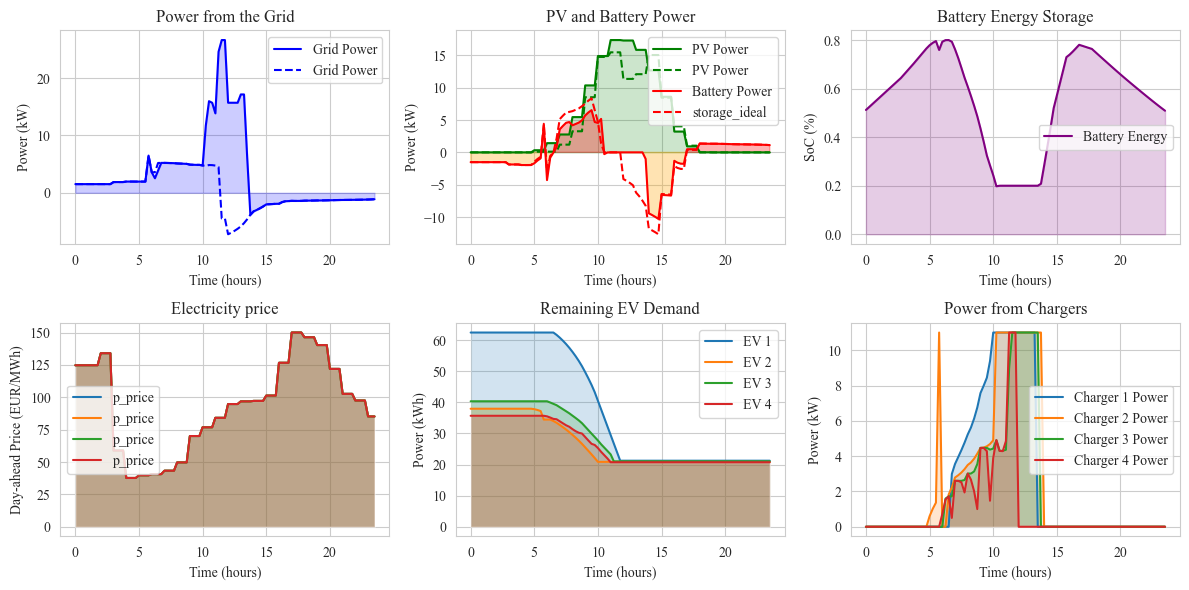

In [229]:
plt.figure(figsize=(12, 6))
time_steps = np.arange(len(results['p_grid'])) / 4  # Scale the time steps to hours

# Plot grid power
plt.subplot(2, 3, 1)
plt.plot(time_steps, results['p_grid'], label='Grid Power', color='blue')
plt.fill_between(time_steps, 0, results['p_grid'], color='blue', alpha=0.2)
plt.plot(time_steps, results['p_grid_ideal'], label='Grid Power', color='blue', linestyle='--')

plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('Power from the Grid')
plt.legend()

# Plot PV power and battery power
plt.subplot(2, 3, 2)
plt.plot(time_steps, expanded_pv[1:1+len(time_steps)]/1000, label='PV Power', color='green')
plt.fill_between(time_steps, 0, expanded_pv[1:1+len(time_steps)]/1000, color='green', alpha=0.2)
plt.plot(time_steps, expanded_pv_forecast[1:1+len(time_steps)]/1000, label='PV Power', color='green', linestyle='--')

plt.plot(time_steps, results['p_storage'], label='Battery Power', color='red')
plt.fill_between(time_steps, 0, results['p_storage'], where=np.array(results['p_storage']) >= 0, color='red', alpha=0.3, interpolate=True)
plt.fill_between(time_steps, 0, results['p_storage'], where=np.array(results['p_storage']) < 0, color='orange', alpha=0.3, interpolate=True)
plt.plot(time_steps, results['p_storage_ideal'], label='storage_ideal', color='red', linestyle='--')

plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('PV and Battery Power')
plt.legend()

# Plot battery energy
plt.subplot(2, 3, 3)
plt.plot(time_steps, np.array(results['storage_energy'])/storage_capacity, label='Battery Energy', color='purple')
plt.fill_between(time_steps, 0, np.array(results['storage_energy'])/storage_capacity, color='purple', alpha=0.2)
plt.xlabel('Time (hours)')
plt.ylabel('SoC (%)')
plt.title('Battery Energy Storage')
plt.legend()

# Plot electricity price
plt.subplot(2, 3, 4)
for i in range(4):
    plt.plot(time_steps, expanded_price[1:1+len(time_steps)], label=f'p_price')
    plt.fill_between(time_steps, 0, expanded_price[1:1+len(time_steps)], alpha=0.2)
plt.xlabel('Time (hours)')
plt.ylabel('Day-ahead Price (EUR/MWh)')
plt.title('Electricity price')
plt.legend()

# Plot EV demand
plt.subplot(2, 3, 5)
for i in range(4):
    plt.plot(time_steps, results['remaining_demand'][:,i], label=f'EV {i+1}')
    plt.fill_between(time_steps, 0, results['remaining_demand'][:,i], alpha=0.2)
plt.xlabel('Time (hours)')
plt.ylabel('Power (kWh)')
plt.title('Remaining EV Demand')
plt.legend()

# Plot charger power
plt.subplot(2, 3, 6)
for i in range(4):
    plt.plot(time_steps, results['p_chargers'][:,i], label=f'Charger {i+1} Power')
    plt.fill_between(time_steps, 0, results['p_chargers'][:,i], alpha=0.2)
plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('Power from Chargers')
plt.legend()

plt.tight_layout()
plt.show()

In [230]:
results['remaining_demand'][-1:].shape

(1, 4)

In [231]:
command['p_chargers'].shape

(1, 4)

In [232]:
np.clip(remaining_demand[3]/mpc.time_resolution, 
                                                0,
                                                mpc.p_charger_limit), remaining_demand[1]

(11.0, 20.85195256712135)

In [233]:
mpc.time_resolution

0.25

In [234]:
remaining_demand[0], mpc.p_charger_limit

(21.22455571896231, 11)

In [235]:
(charger_availability_real[1:time_shift+1] - charger_availability[1:time_shift+1]).shape

(1, 4)

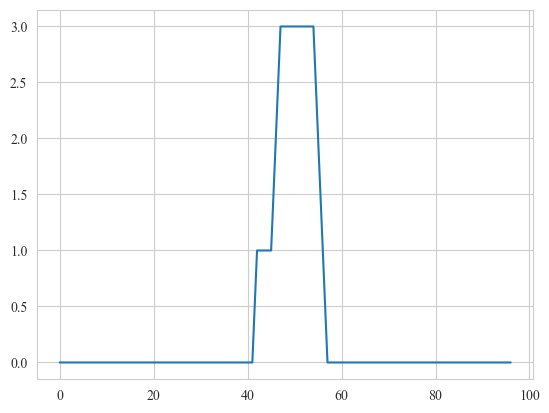

In [236]:
plt.plot(np.sum(real_availability-est_availability, axis=1))

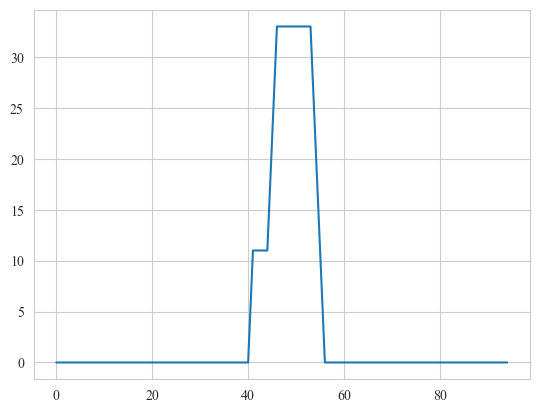

In [237]:
plt.plot(np.array(ev_errors).flatten())

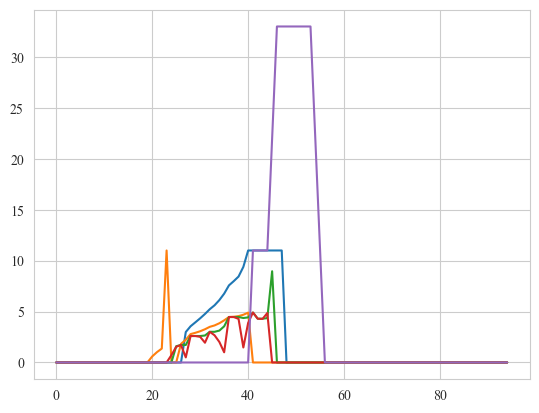

In [238]:
plt.plot(results['p_chargers_ideal'])
plt.plot(np.array(ev_errors).flatten())

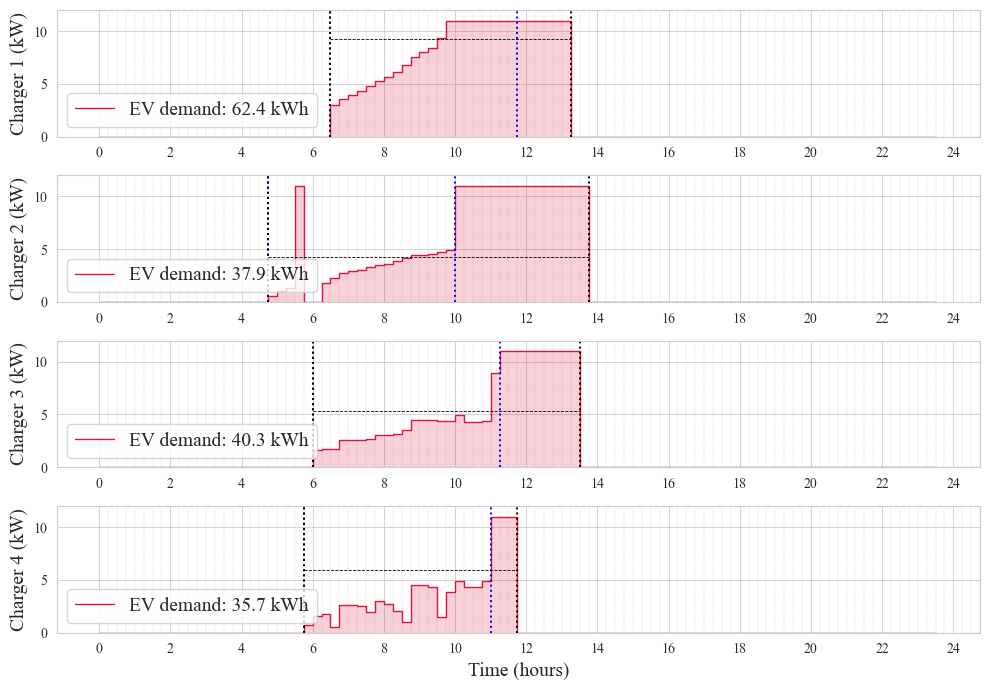

In [242]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'Times New Roman'

# Create figure and first set of axes
fig, axes = plt.subplots(4, 1, figsize=(10, 7))

for i in range(len(axes)):
    # Plot for ax1 (Battery Power)
    axes[i].fill_between(time_steps, results['p_chargers'][:,i], color='crimson', alpha=0.2, edgecolor='None', step="pre")
    line1, = axes[i].plot(time_steps, results['p_chargers'][:,i], color='crimson', linewidth=1, drawstyle='steps', label=f'EV demand: {real_energies_initial[0,i]:.1f} kWh')

    ts = np.where(est_availability[1:,i]>0)
    axes[i].axvline(x = (np.min(ts)-1)/4, color = 'blue', linestyle=':', linewidth=1.4)
    axes[i].axvline(x = (np.max(ts))/4, color = 'blue', linestyle=':', linewidth=1.4)

    ts = np.where(real_availability[1:,i]>0)
    axes[i].axvline(x = (np.min(ts)-1)/4, color = 'black', linestyle=':', linewidth=1.4)
    axes[i].axvline(x = (np.max(ts))/4, color = 'black', linestyle=':', linewidth=1.4)

    charging_time = np.arange(np.min(ts)-1, np.max(ts)+1)/4
    axes[i].plot(charging_time, np.repeat(real_energies_initial[0,i]/(max(charging_time)-min(charging_time)), len(charging_time)) , color = 'black', linestyle='--', linewidth=0.6)

    axes[i].set_ylabel(f'Charger {i+1} (kW)', size=14)
    axes[i].set_ylim([0, 12])
    axes[i].grid(True, which='minor', linestyle='--', linewidth=0.3)
    axes[i].grid(True, which='major', linestyle='-', linewidth=0.6)

    # Set x-axis ticks
    minor_hours = np.arange(0, 25, 0.25)
    major_hours = np.arange(0, 25, 2)
    axes[i].set_xticks(minor_hours, minor=True)
    axes[i].set_xticks(major_hours, minor=False)

    # # Combine legends from both axes
    axes[i].legend(loc='lower left', fontsize=14)

axes[i].set_xlabel('Time (hours)', size=14)
plt.tight_layout()
# Save the figure
plt.savefig('res_chargers.png', dpi=300, bbox_inches='tight', pad_inches=0.1)


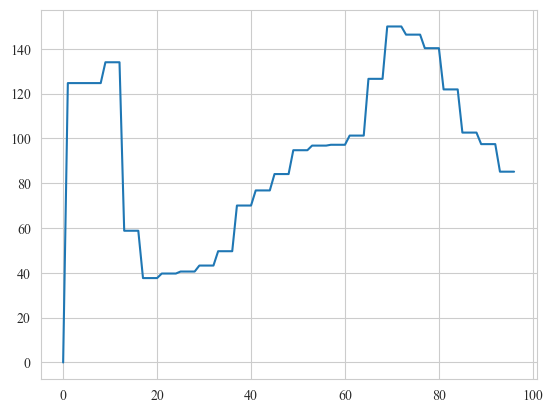

In [114]:
plt.plot(expanded_price)

In [115]:
mpc.p_chargers_slack.value

array([ -8.84814228, -18.15960374, -18.87757107, -20.86169505])

In [116]:
new_est_durations

array([3.6288686], dtype=float32)

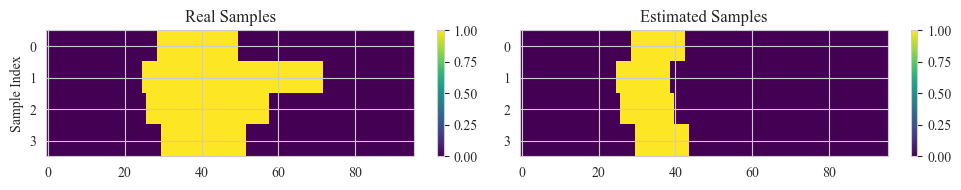

In [117]:
# Plotting with imshow
fig, axs = plt.subplots(1, 2, figsize=(10, 2))

im0 = axs[0].imshow(real_availability_matrix, aspect='auto', cmap='viridis')
axs[0].set_title("Real Samples")
axs[0].set_yticks(range(4))
axs[0].set_ylabel("Sample Index")
plt.colorbar(im0, ax=axs[0])

im1 = axs[1].imshow(est_availability_matrix, aspect='auto', cmap='viridis')
axs[1].set_title("Estimated Samples")
axs[1].set_yticks(range(4))
plt.colorbar(im1, ax=axs[1])

plt.tight_layout()
plt.show()


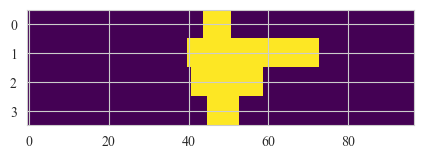

In [118]:
plt.figure(figsize=(5, 1.5))
plt.imshow((real_availability - est_availability).T, aspect='auto', cmap='viridis')

In [ ]:
charger_availability_real - charger_availability

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

In [ ]:
real_durations

array([5.3452883, 6.139223 , 7.243389 , 6.25282  ], dtype=float32)

In [ ]:
# Sample once for real
real_arrivals, real_durations, real_energies = get_filtered_samples(mdn1, mdn2, mdn3)

# Sample once for estimate
est_arrivals, est_durations, est_energies = get_filtered_samples(mdn1, mdn2, mdn3)

real_availability_matrix = compute_availability(real_arrivals, real_durations)
est_availability_matrix = compute_availability(est_arrivals, est_durations)

In [ ]:
est_availability_matrix

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0,

In [ ]:
est_availability_matrix

array([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 1],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0,

In [ ]:
t in (real_arrivals*4).astype(int)

True

In [ ]:
(real_arrivals*4).astype(int) == t

array([False, False,  True, False])

In [ ]:
est_arrivals[np.where((real_arrivals*4).astype(int) == t)] = t

In [ ]:
est_arrivals

array([ 7.517053 ,  8.188163 , 31.       ,  5.2306805], dtype=float32)